# Declaration of Originality

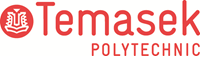

**TEMASEK POLYTECHNIC**
<br>**SCHOOL OF INFORMATICS & IT**
<br>**DIPLOMA IN INFORMATION TECHNOLOGY**
<br>**MACHINE LEARNING FOR DEVELOPERS (CAI2C08)**
<br>**AY2025/2026 OCTOBER SEMESTER**

**PROJECT PROGRAM CODES**
* Student Name (Matric Number)  : Yap Kai Feng (2404747D)
* Tutorial Group                : TC03
* Tutor						    : Ruchir Srivastava
* Submission Date               : 13 February 2026


**Declaration of Originality**
* I am the originator of this work and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [337]:
## Import libraries
import matplotlib.pyplot as plt
import numpy as np

# import pandas library
import pandas as pd
import seaborn as sns

# 1. Business Understanding
Goal: Predict marketing campaign by response of customers

# 2. Data Understanding

## 2.1 Load dataset

In [338]:
## Read *.csv file into pandas DataFrame
FILE_PATH = "ifood_df.csv"
df = pd.read_csv(FILE_PATH)

df ## Display dataframe
## Predicting Classification of marketing data of target variable 'Response' if customer will respond to a last marketing campaign or not

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n_Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2200,61223,0,1,46,709,43,182,42,118,247,...,0,0,0,0,1,0,0,1094,847,0
2201,64014,2,1,56,406,0,30,0,0,8,...,1,0,0,0,0,0,1,436,428,1
2202,56981,0,0,91,908,48,217,32,12,24,...,0,0,0,0,1,0,0,1217,1193,1
2203,69245,0,1,8,428,30,214,80,30,61,...,1,0,0,0,0,1,0,782,721,0


## 2.2 Summary Statistics

In [339]:
## Understand the type of variable for each column
df.dtypes

Income                  int64
Kidhome                 int64
Teenhome                int64
Recency                 int64
MntWines                int64
MntFruits               int64
MntMeatProducts         int64
MntFishProducts         int64
MntSweetProducts        int64
MntGoldProds            int64
NumDealsPurchases       int64
NumWebPurchases         int64
NumCatalogPurchases     int64
NumStorePurchases       int64
NumWebVisitsMonth       int64
AcceptedCmp3            int64
AcceptedCmp4            int64
AcceptedCmp5            int64
AcceptedCmp1            int64
AcceptedCmp2            int64
Complain                int64
Z_CostContact           int64
Z_Revenue               int64
Response                int64
Age                     int64
Customer_Days           int64
marital_Divorced        int64
marital_Married         int64
marital_Single          int64
marital_Together        int64
marital_Widow           int64
education_2n_Cycle      int64
education_Basic         int64
education_

type of variable for each column are integers

In [340]:
## Check for missing data
df.isna().sum()

Income                  0
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
Age                     0
Customer_Days           0
marital_Divorced        0
marital_Married         0
marital_Single          0
marital_Together        0
marital_Widow           0
education_2n_Cycle      0
education_Basic         0
education_Graduation    0
education_Master        0
education_PhD           0
MntTotal                0
MntRegularProds         0
AcceptedCmpO

There is no missing data in this dataset

In [341]:
## Describe data distribution
df.describe(include = "all")

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n_Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

In [342]:
## Understanding distribution of target
col_y = 'Response' # Choose target variable

### 2.3.1.2 Understanding distribution of features

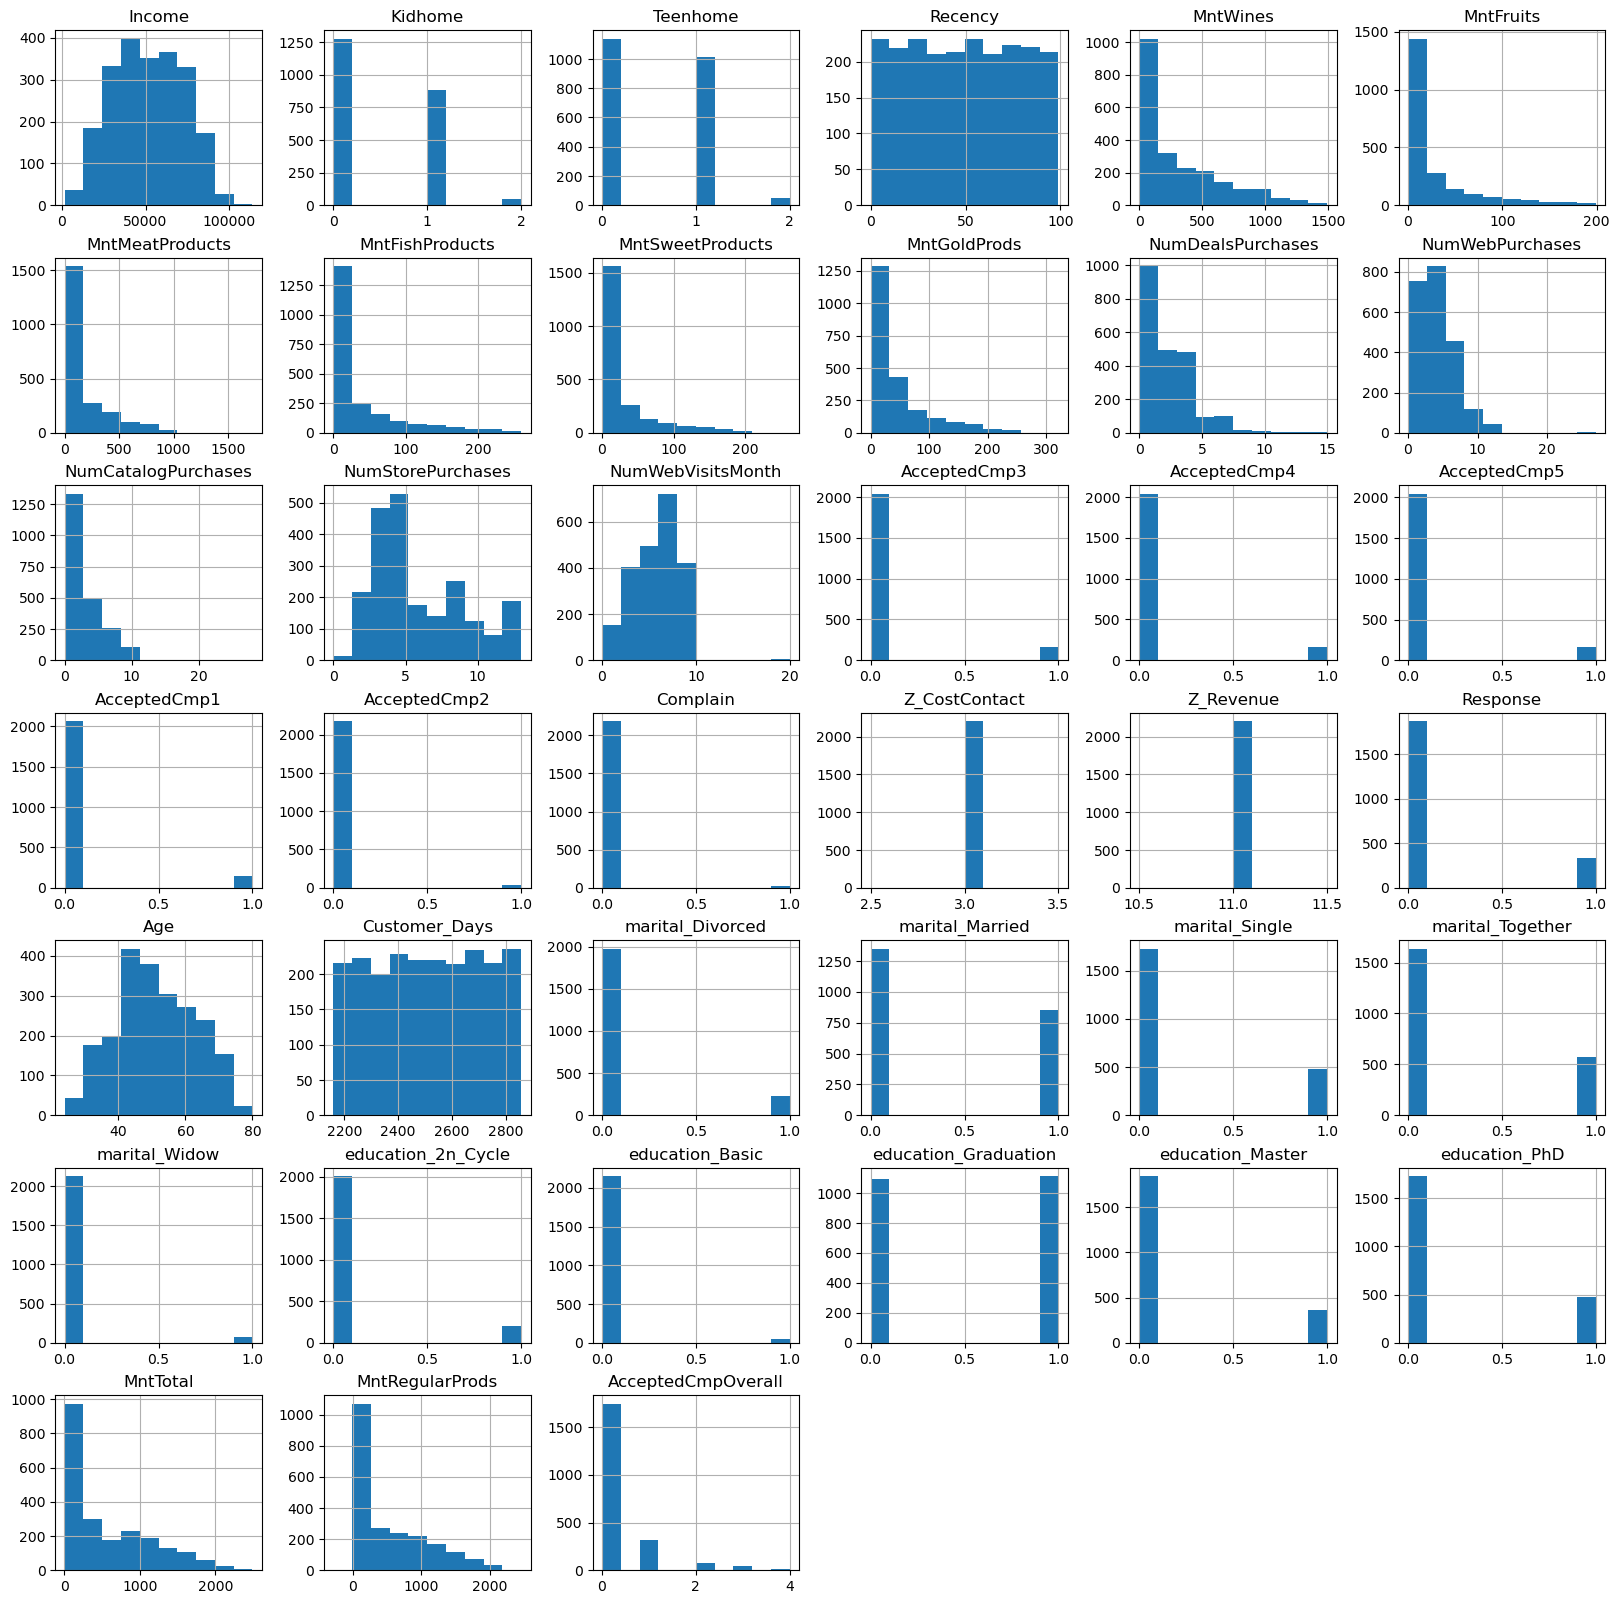

In [343]:
## Understanding distribution of features
df.hist(figsize=(20,20))
plt.show()

#### Skewed distribution of different values

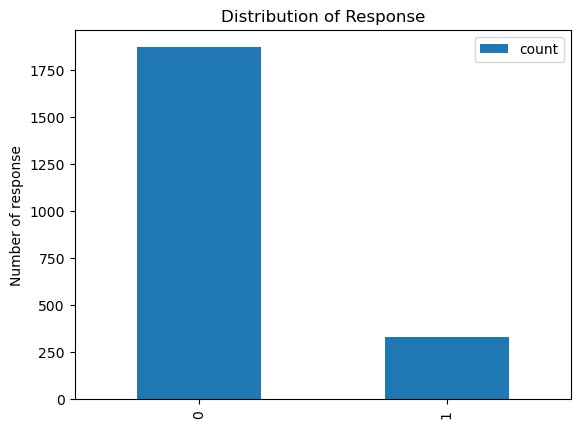

In [344]:
# Tally unique values
df[col_y].value_counts()
plt.show()

# plot bar chart
df[col_y].value_counts().plot(kind='bar')
plt.title(f'Distribution of {col_y}')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()
# class imbalance

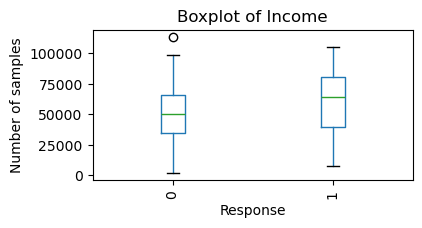

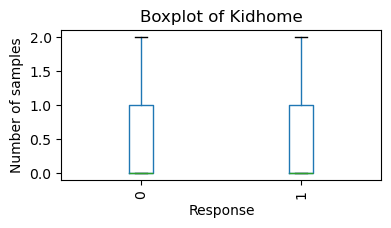

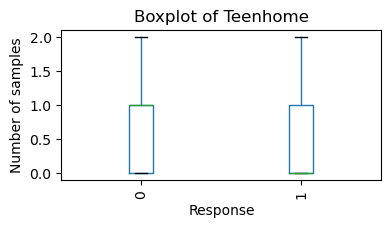

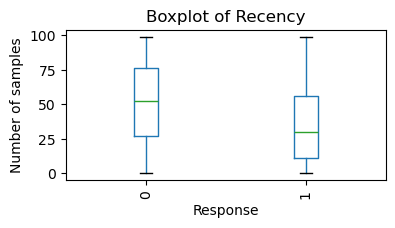

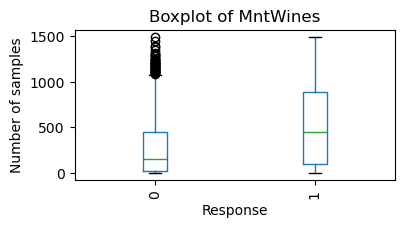

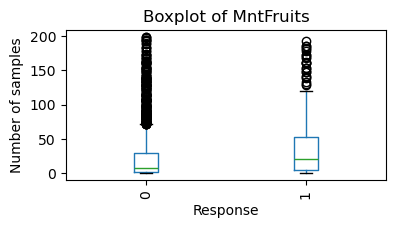

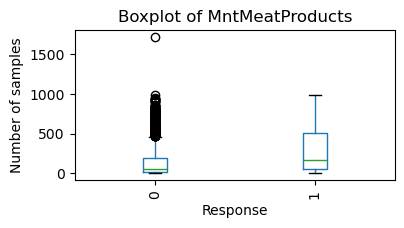

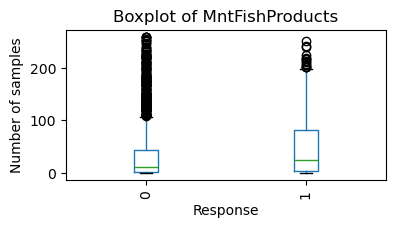

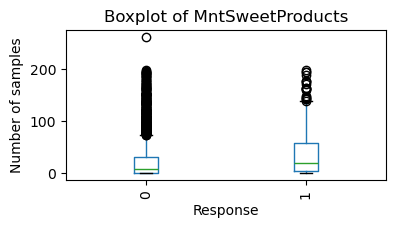

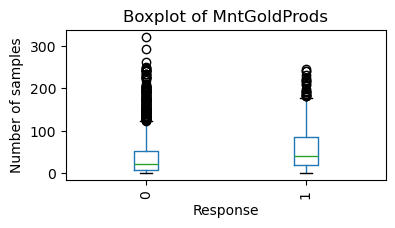

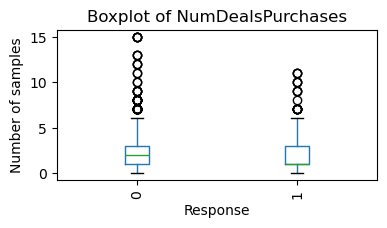

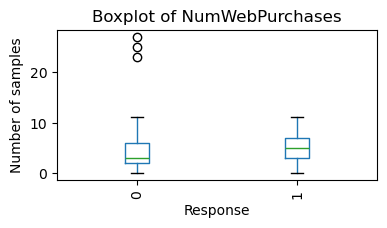

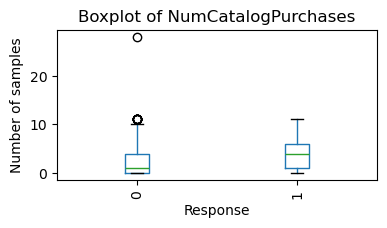

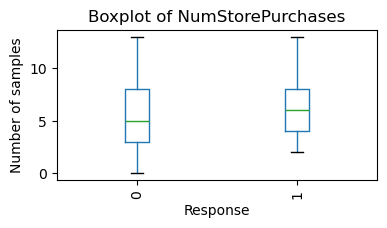

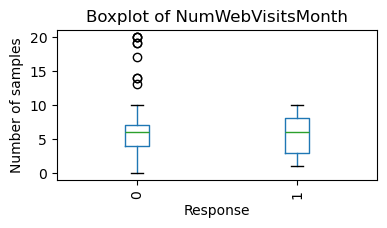

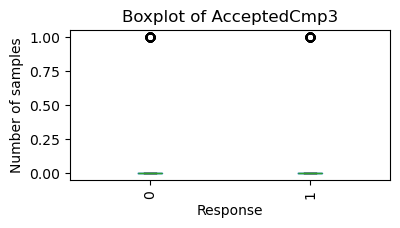

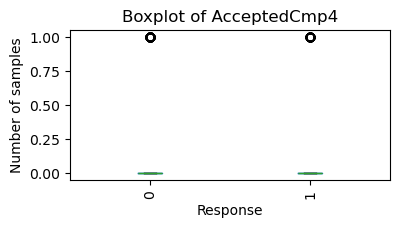

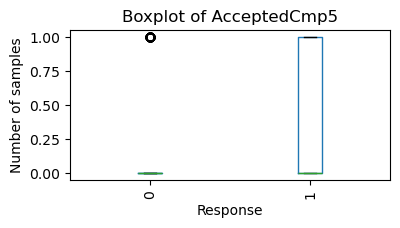

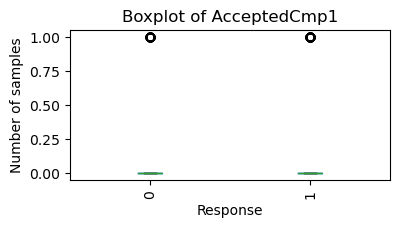

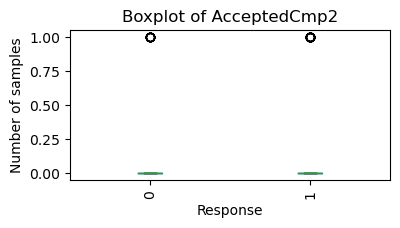

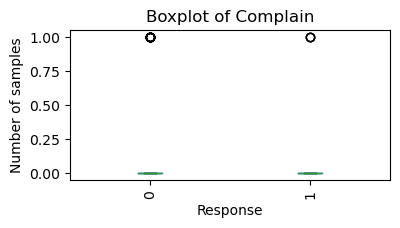

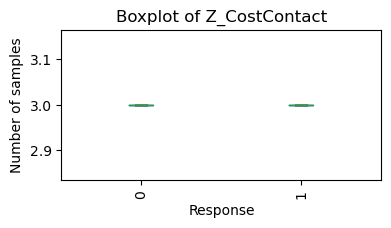

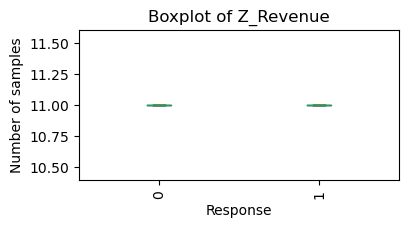

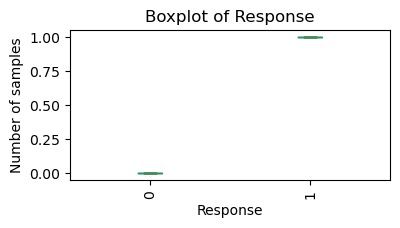

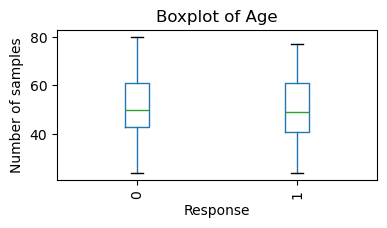

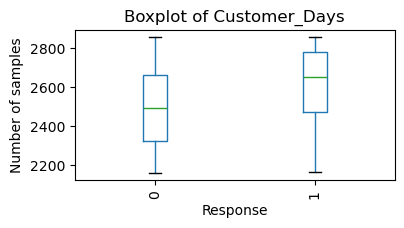

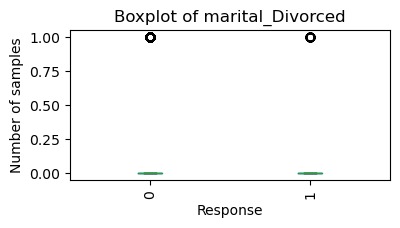

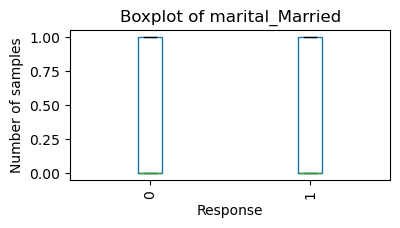

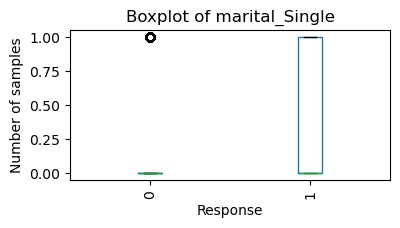

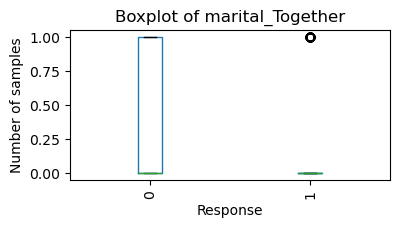

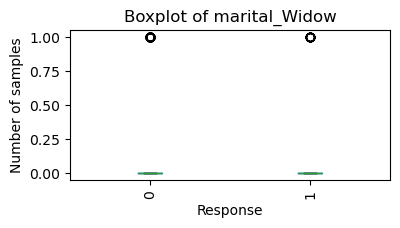

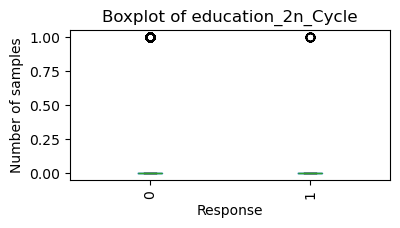

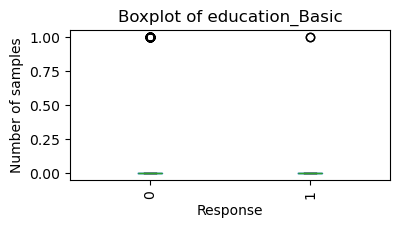

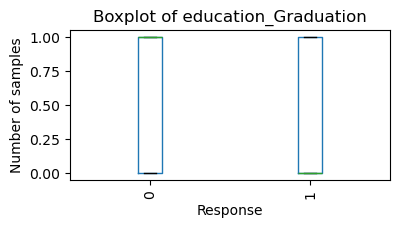

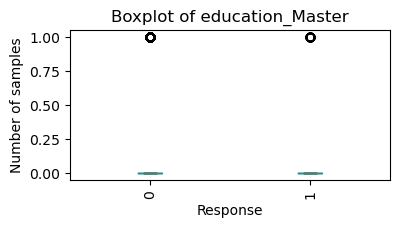

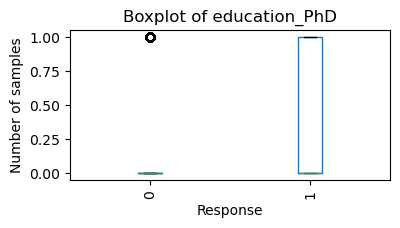

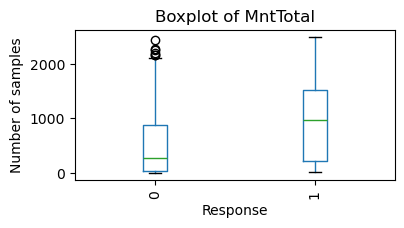

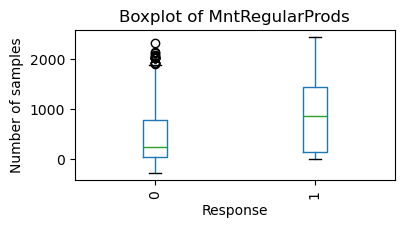

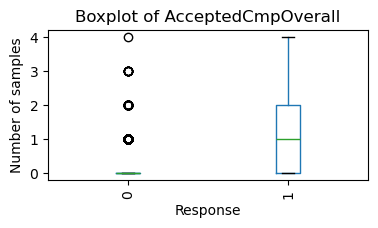

In [345]:
## Plot boxplot for different features grouped by Response
for col in df.columns:
    if df[col].dtype==int or df[col].dtype==float:
 
        df.boxplot(column=col,
                   by='Response',
                   grid=False,
                   rot=90,
                   figsize=(4,2))
        plt.title(f"Boxplot of {col}")
        plt.suptitle('')  # Remove default title by Pandas
        plt.xlabel("Response")
        plt.ylabel("Number of samples")
        plt.show()
        # there are a lot of outliers in boxplots

### there are extreme ouliers in this dataset according to boxplot

### 2.3.2 Understanding relationship between variables

In [346]:
## Understanding relationship between variables
df.corr()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n_Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
Income,1.000000,-0.531699,0.042483,0.006716,0.730495,0.537920,0.702500,0.551758,0.555601,0.417653,...,-0.001960,0.044336,-0.060621,-0.239604,0.017644,0.021633,0.091176,0.823066,0.816879,0.388247
Kidhome,-0.531699,1.000000,-0.040207,0.011829,-0.499288,-0.374388,-0.445665,-0.389895,-0.379101,-0.356550,...,0.007422,-0.072244,0.019050,0.055308,-0.001930,0.011482,-0.042031,-0.551152,-0.539828,-0.212080
Teenhome,0.042483,-0.040207,1.000000,0.013881,0.002783,-0.176925,-0.267177,-0.206371,-0.164246,-0.019619,...,0.027181,0.047962,-0.056259,-0.120519,-0.024698,0.023806,0.092901,-0.142995,-0.146866,-0.130255
Recency,0.006716,0.011829,0.013881,1.000000,0.016470,-0.004909,0.026138,0.001177,0.025535,0.018558,...,0.023908,-0.001348,-0.006789,-0.003093,0.031419,-0.025563,-0.009234,0.021132,0.020241,-0.013344
MntWines,0.730495,-0.499288,0.002783,0.016470,1.000000,0.384947,0.593119,0.395967,0.388613,0.390194,...,0.005915,0.034139,-0.096259,-0.140369,-0.060920,0.036403,0.160804,0.902310,0.901848,0.509913
MntFruits,0.537920,-0.374388,-0.176925,-0.004909,0.384947,1.000000,0.568100,0.592556,0.570986,0.392596,...,-0.014210,0.025961,0.025452,-0.060915,0.114919,-0.055581,-0.084301,0.606658,0.594180,0.155133
MntMeatProducts,0.702500,-0.445665,-0.267177,0.026138,0.593119,0.568100,1.000000,0.595673,0.556511,0.375581,...,-0.004064,0.017370,-0.041738,-0.111968,0.064917,-0.004020,-0.004194,0.861392,0.860663,0.319553
MntFishProducts,0.551758,-0.389895,-0.206371,0.001177,0.395967,0.592556,0.595673,1.000000,0.582974,0.425420,...,0.015502,0.041886,0.061304,-0.059840,0.106227,-0.050153,-0.103952,0.635038,0.620626,0.174675
MntSweetProducts,0.555601,-0.379101,-0.164246,0.025535,0.388613,0.570986,0.556511,0.582974,1.000000,0.355747,...,-0.011220,0.049347,0.060550,-0.057863,0.104075,-0.067723,-0.085702,0.604514,0.595394,0.200174
MntGoldProds,0.417653,-0.356550,-0.019619,0.018558,0.390194,0.392596,0.375581,0.425420,0.355747,1.000000,...,-0.010375,0.043096,0.019189,-0.065014,0.131759,-0.032492,-0.119708,0.463694,0.388776,0.194647


### There are negative correlations in some values

In [347]:
# sns.pairplot(df, hue='Response') ## Pairplot of all columns colored by Response
# plt.show()

#### Response 0 has more votes than Response 1 across all features
#### There are outliers in the dataset

# 3. Data Preparation

## 3.1 Data Cleaning

In [348]:
# Cap outliers for selected columns
col_tocap = ['Income','MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds','NumDealsPurchases','NumWebVisitsMonth','NumWebPurchases','NumCatalogPurchases','MntTotal','MntRegularProds']  # List of columns to cap outliers
for col in col_tocap:
    if col in df.columns:
        #Calling mean to cap outliers
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + 1.5 * IQR

        df.loc[ df[col] > upper_bound, col] = upper_bound.astype(df[col].dtype)  # cap outlier

In [349]:
## Clean data
col_irrelevant = [col_y,'AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','AcceptedCmpOverall']  # List of irrelevant columns
X = df.drop(col_irrelevant, axis=1)  #remove irrelevant columns (including target)
X

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Single,marital_Together,marital_Widow,education_2n_Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds
0,58138,0,0,58,635,79,546,120,83,88,...,1,0,0,0,0,1,0,0,1529,1441
1,46344,1,1,38,11,1,6,2,1,6,...,1,0,0,0,0,1,0,0,21,15
2,71613,0,0,26,426,49,127,111,21,42,...,0,1,0,0,0,1,0,0,734,692
3,26646,1,0,26,11,4,20,10,3,5,...,0,1,0,0,0,1,0,0,48,43
4,58293,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,0,1,407,392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2200,61223,0,1,46,709,43,182,42,83,126,...,0,0,0,0,0,1,0,0,1094,847
2201,64014,2,1,56,406,0,30,0,0,8,...,0,1,0,0,0,0,0,1,436,428
2202,56981,0,0,91,908,48,217,32,12,24,...,0,0,0,0,0,1,0,0,1217,1193
2203,69245,0,1,8,428,30,214,80,30,61,...,0,1,0,0,0,0,1,0,782,721


In [350]:
## Handling Categorical Data (One-Hot Encoding)
y = df[col_y]  ## Select target column which is col_y = Response

In [351]:
## One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)  # encode categorical columns
X

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Single,marital_Together,marital_Widow,education_2n_Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds
0,58138,0,0,58,635,79,546,120,83,88,...,1,0,0,0,0,1,0,0,1529,1441
1,46344,1,1,38,11,1,6,2,1,6,...,1,0,0,0,0,1,0,0,21,15
2,71613,0,0,26,426,49,127,111,21,42,...,0,1,0,0,0,1,0,0,734,692
3,26646,1,0,26,11,4,20,10,3,5,...,0,1,0,0,0,1,0,0,48,43
4,58293,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,0,1,407,392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2200,61223,0,1,46,709,43,182,42,83,126,...,0,0,0,0,0,1,0,0,1094,847
2201,64014,2,1,56,406,0,30,0,0,8,...,0,1,0,0,0,0,0,1,436,428
2202,56981,0,0,91,908,48,217,32,12,24,...,0,0,0,0,0,1,0,0,1217,1193
2203,69245,0,1,8,428,30,214,80,30,61,...,0,1,0,0,0,0,1,0,782,721


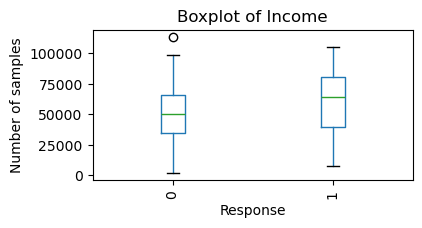

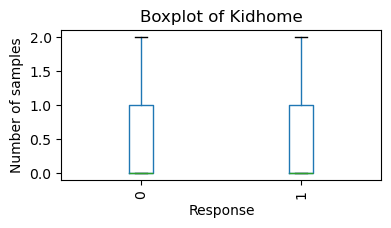

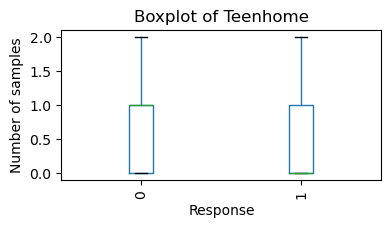

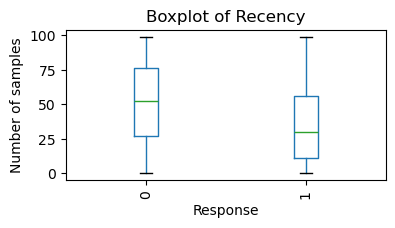

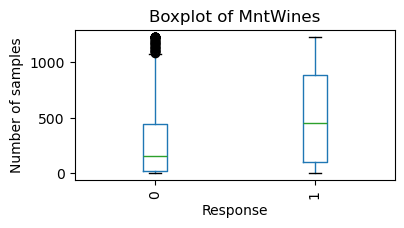

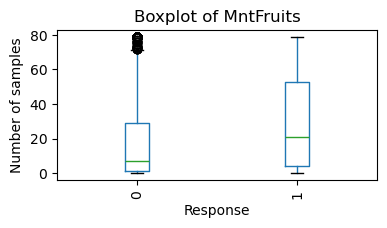

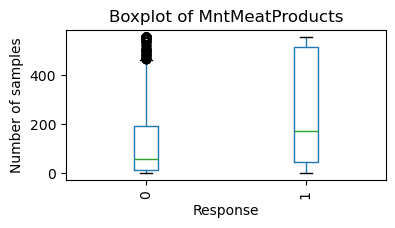

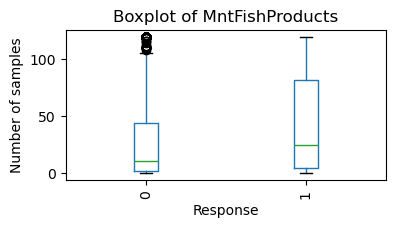

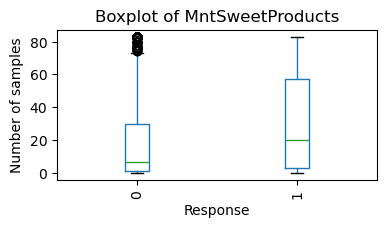

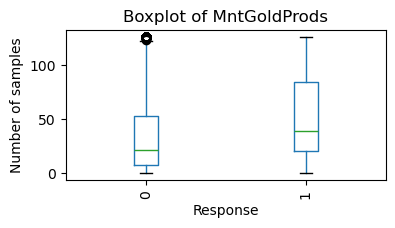

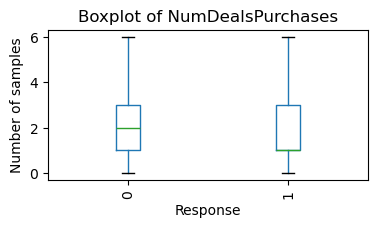

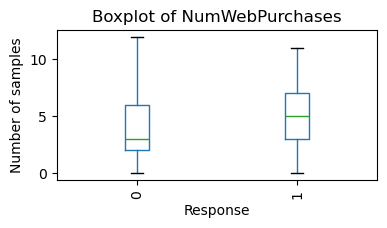

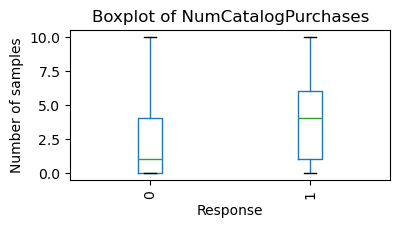

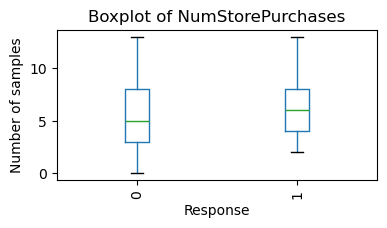

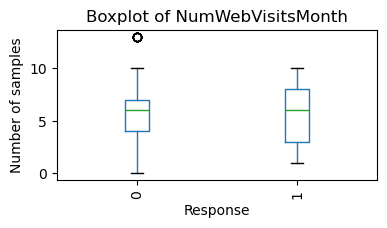

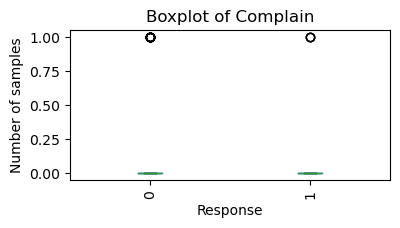

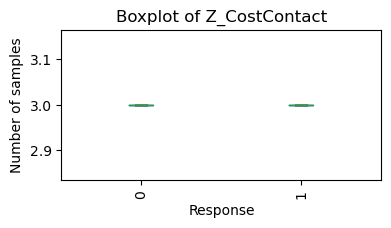

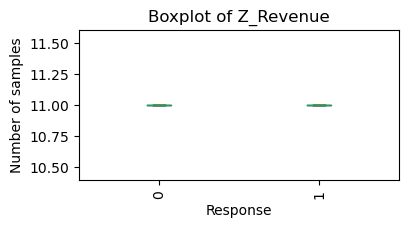

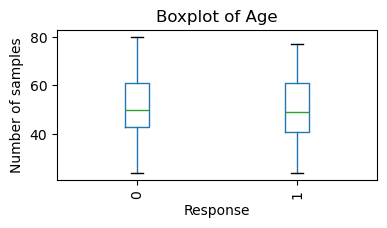

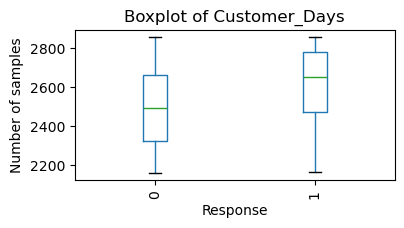

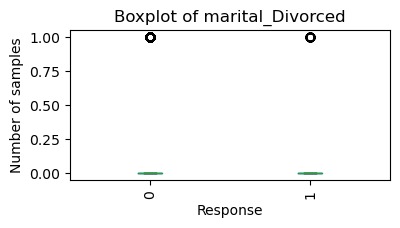

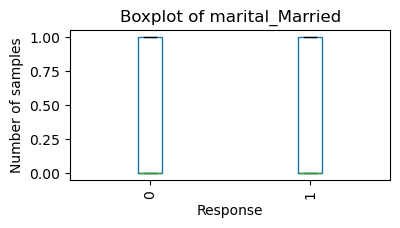

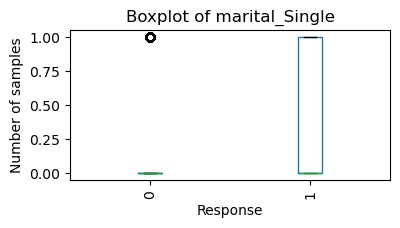

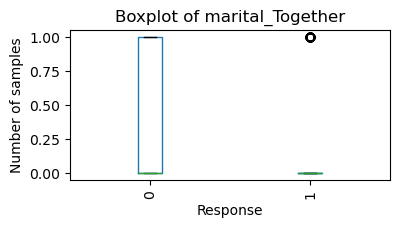

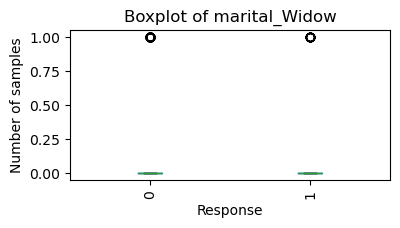

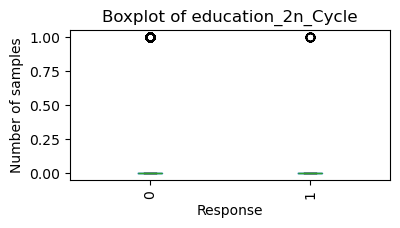

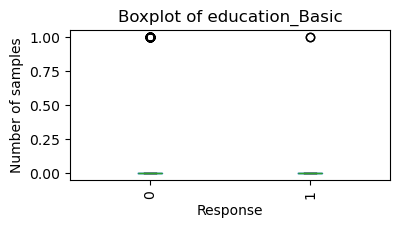

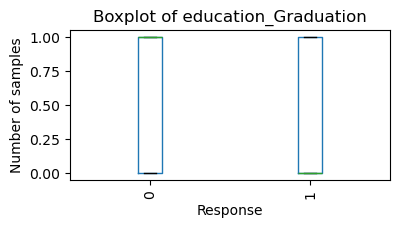

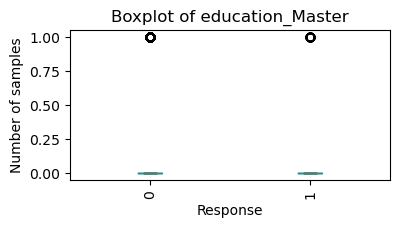

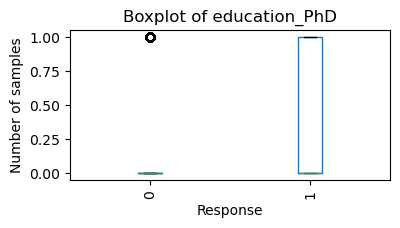

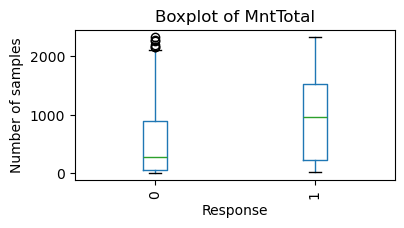

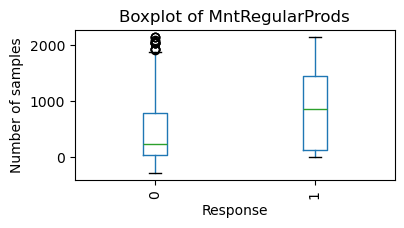

In [352]:

df[col_y].value_counts()
## Plot boxplot for different features grouped by Response
for col in X.columns:
    if col != col_y and np.issubdtype(X[col].dtype, np.number):

        df.boxplot(column=col,
                   by='Response',
                   grid=False,
                   rot=90,
                   figsize=(4,2))
        plt.title(f"Boxplot of {col}")
        plt.suptitle('')  # Remove default title by Pandas
        plt.xlabel("Response")
        plt.ylabel("Number of samples")
        plt.show()
        # there are fewer extreme outliers after capping outliers from selected columns

## 3.2 Train-Test Split

In [353]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split
test_size = 0.5
random_state = 20 ## for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state) # Split the data


# 4. Modelling

### 4.2 Train Model

### using decision tree to see exactly which features trigger which outcome to extract logical rules, aiding in marketing campaigns.

In [354]:
## Initialise and train model
from sklearn.tree import DecisionTreeClassifier

## Initialise model
dt = DecisionTreeClassifier()  # Initialise Decision Tree Classifier

## Train model
dt.fit(X_train, y_train)  # pass training set to model

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### I chose LogisticRegression for classification as it is frequently used for business for market optimization as it allows to model the impact of different variables on marketing outcomes.

In [355]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
## Initialise the models
logr = LogisticRegression(max_iter=100)  # Initialise Logistic Regression
lda = LinearDiscriminantAnalysis()
## Train model
logr.fit(X_train, y_train)  # pass training set to model

c:\Users\Yap Kai Feng\anaconda3\envs\mldp\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### I chose GradientBoostingClassifier to provide high predictive accuracy by focusing on residual errors rather on averaging predictions and identify and analyze customer behaviour.

In [356]:
# Gradient Boosted Tree
from sklearn.ensemble import GradientBoostingClassifier
gbt = GradientBoostingClassifier()  # Initialise GradientBoostingClassifier
gbt.fit(X_train, y_train)  #  gbt.fit(...)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


#### I chose RandomForestClassifier as it handles Imbalanced data effectively according to evidence and can detect fradualent by analyzing  patterns and anomalies based on user behavior.

In [357]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()  #  Initialise RandomForestClassifier
rf.fit(X_train, y_train)  # rf.fit(...) Random Forest

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# 5. Model Evaluation

In [358]:
## Evaluate model
## Make predictions on the test set using X_test to determine model accuracy
from sklearn.metrics import accuracy_score
y_pred_dt = dt.predict(X_test)  #  dt.predict(...) pre
print("Decision Tree Accuracy: ", accuracy_score(y_test, y_pred_dt))  # use accuracy_score(...)


Decision Tree Accuracy:  0.7923844061650045


In [359]:
## Make predictions on the test set using X_test to determine model accuracy

## Evaluate model

y_pred_logr = logr.predict(X_test)

## Calculate the accuracy of the model
from sklearn.metrics import accuracy_score
print("Logistic Regression Accuracy: ", accuracy_score(y_test, y_pred_logr))

Logistic Regression Accuracy:  0.8640072529465095


In [360]:
# Randomized Search CV
from scipy.stats import randint, uniform

# Randomized Search CV parameters
param_dist_rf = {
    'n_estimators': randint(1, 5), # create randint of range 1 to 5 trees 
    'criterion': ['gini', 'entropy'], #measure quality of split, supported criteria: 'gini' for gini impurity and 'entropy
    'max_depth': randint(1, 3), # maximum depth of tree
    'min_samples_split': randint(2, 5), # minimum number of samples requied to split internal node
    'max_features': ['sqrt', 'log2'], #number of features to consider when looking for best split
    'max_samples': uniform(0.6, 0.4) #number of samples to draw from X to train each base estimator
}

In [361]:
# Randomized Search CV
from scipy.stats import randint, uniform

# Randomized Search CV parameters
param_dist_dt = {
    'criterion': ['gini', 'entropy'], #measure quality of split, supported criteria: 'gini' for gini impurity and 'entropy
    'max_depth': randint(1, 10), # maximum depth of tree
    'min_samples_split': randint(2, 5), # minimum number of samples requied to split internal node
    'min_samples_leaf': randint(1, 5), # minimum number of samples required to be at a leaf node
    'max_features': ['sqrt', 'log2'], #number of features to consider when looking for best split
}

In [362]:
# Randomized Search CV
from scipy.stats import randint, uniform

# Randomized Search CV parameters
param_dist_logr = {
    'C': uniform(0.01, 10), #Inverse of regularization strength
    'penalty': ['l2'], #Used to specify the norm used in the penalization
    'solver': ['saga', 'liblinear'], #Algorithm to use in the optimization problem
    'max_iter': randint(100, 500), #Maximum number of iterations taken for the solvers to converge
}

In [363]:
# Randomized Search CV
from scipy.stats import randint, uniform

# Randomized Search CV parameters
param_dist_gbt = {
    'n_estimators': randint(1, 5), # create randint of range 1 to 5 trees 
    'criterion': ['friedman_mse', 'squared_error'], #measure quality of split, supported criteria: 'gini' for gini impurity and 'entropy
    'max_depth': randint(1, 10), # maximum depth of tree
    'min_samples_split': randint(2, 5), # minimum number of samples requied to split internal node
    'min_samples_leaf': randint(1, 5), # minimum number of samples required to be at a leaf node
    'max_features': ['sqrt', 'log2'], #number of features to consider when looking for best split
}

In [364]:
model = dt  # TODO: choose model for prediction

In [365]:
## Save model
import joblib
joblib.dump(dt, 'ifood_df_model_dt.joblib')  # TODO: Save model using joblib.dump(...)

['ifood_df_model_dt.joblib']

In [366]:
joblib.dump(logr, 'ifood_df_model_logr.joblib')  # Save model using joblib.dump(...)

['ifood_df_model_logr.joblib']

In [367]:
# Gradient Boosted Tree Predictions to determine model accuracy
y_pred_gbt = gbt.predict(X_test)  #  gbt.predict(...)
print("Gradient Boosted Tree Accuracy: ", accuracy_score(y_test, y_pred_gbt)) # print accuracy score
joblib.dump(gbt, 'ifood_df_gbt_model.joblib')  #  Save model

Gradient Boosted Tree Accuracy:  0.8558476881233001


['ifood_df_gbt_model.joblib']

In [368]:
# Random Forest Predictions to determine model accuracy
y_pred_rf = rf.predict(X_test)  # predict Random Forest
print("Random Forest Accuracy: ", accuracy_score(y_test, y_pred_rf)) # print accuracy score
joblib.dump(rf, 'ifood_df_rf_model.joblib')  # Save model

Random Forest Accuracy:  0.8649138712601995


['ifood_df_rf_model.joblib']

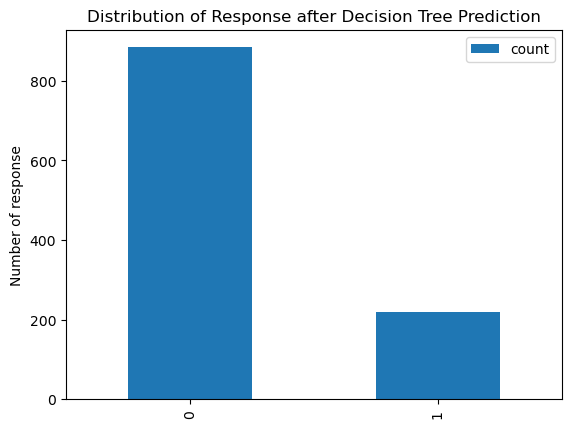

In [369]:
pd.Series(y_pred_dt).value_counts().plot(kind='bar')

plt.title(f'Distribution of Response after Decision Tree Prediction')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()
# There are more responses predicted as 0 than 1 after Decision Tree Prediction
# Using Decision Tree to predict the number of responses
# where predictions are voted by multiple decision trees

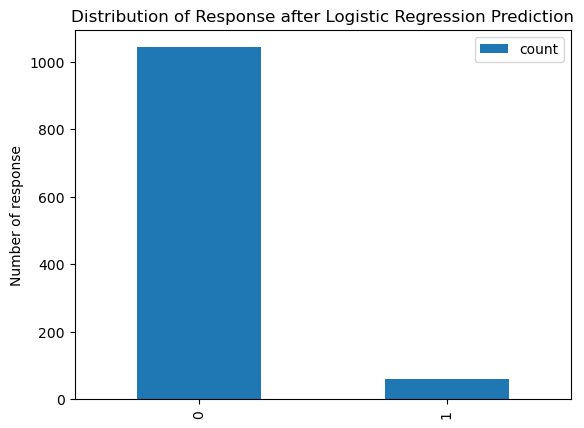

In [370]:
pd.Series(y_pred_logr).value_counts().plot(kind='bar')

plt.title(f'Distribution of Response after Logistic Regression Prediction')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response") 
plt.show()
# There are more responses predicted as 0 than 1 after Logistic Regression Prediction
# Using Logistic Regression to classify and calculate the probability of the categorical outcome of the number of responses
# based on one or more predictor variables

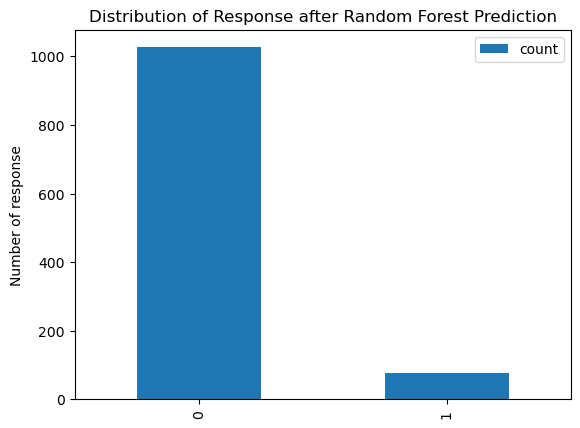

In [371]:
pd.Series(y_pred_rf).value_counts().plot(kind='bar')

plt.title(f'Distribution of Response after Random Forest Prediction')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()
# There are more responses predicted as 0 than 1 after Random Forest Prediction
# Using Random Forest to predict randomly to balance the number of responses
# where predictions are voted by multiple decision trees

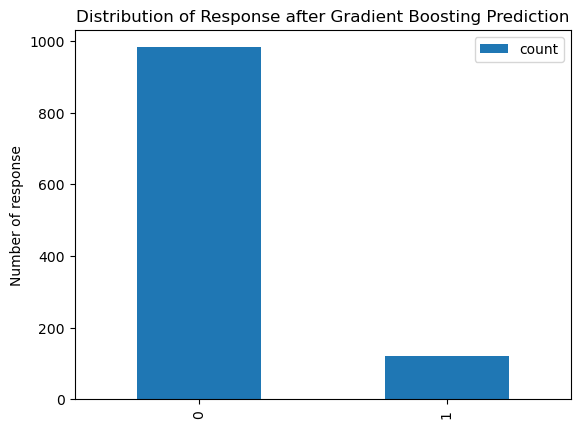

In [372]:
pd.Series(y_pred_gbt).value_counts().plot(kind='bar')

plt.title(f'Distribution of Response after Gradient Boosting Prediction')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()
# There are more responses predicted as 0 than 1 after Gradient Boosting Prediction
# Using Gradient Boosting to predict sequentially to balance the number of responses
# where predictions are corrected iteratively by focusing on misclassified samples

In [373]:
# RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
rs_rf = RandomizedSearchCV(
    estimator = rf, # initialized model
    param_distributions = param_dist_rf,#Search grid (list of parameters)
    cv = 5, # 5 folds for cross validation that divides training set into 5 parts
    scoring = 'neg_mean_squared_error', # Evaluation used to Evaluate validation set
    n_iter = 10, # number of different combinations to try out
    n_jobs = -1 # Controlling how many CPU cores to use -1: Use all available CPU cores
)
rs_rf.fit(X_train, y_train) # pass training set to model

,estimator,RandomForestClassifier()
,param_distributions,"{'criterion': ['gini', 'entropy'], 'max_depth': <scipy.stats....00276DFFED860>, 'max_features': ['sqrt', 'log2'], 'max_samples': <scipy.stats....00276E1E3EC10>, ...}"
,n_iter,10
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [374]:
# RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
rs_dt = RandomizedSearchCV(
    estimator = dt, # initialized model
    param_distributions = param_dist_dt,#Search grid (list of parameters)
    cv = 5, # 5 folds for cross validation that divides training set into 5 parts
    scoring = 'neg_mean_squared_error', # Evaluation used to Evaluate validation set
    n_iter = 10, # number of different combinations to try out
    n_jobs = -1 # Controlling how many CPU cores to use -1: Use all available CPU cores
)
rs_dt.fit(X_train, y_train) # pass training set to model

,estimator,DecisionTreeClassifier()
,param_distributions,"{'criterion': ['gini', 'entropy'], 'max_depth': <scipy.stats....00276E0855080>, 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': <scipy.stats....00276E5FA6740>, ...}"
,n_iter,10
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [375]:
# RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
rs_gbt = RandomizedSearchCV(
    estimator = gbt, # initialized model
    param_distributions = param_dist_gbt,#Search grid (list of parameters)
    cv = 5, # 5 folds for cross validation that divides training set into 5 parts
    scoring = 'neg_mean_squared_error', # Evaluation used to Evaluate validation set
    n_iter = 10, # number of different combinations to try out
    n_jobs = -1 # Controlling how many CPU cores to use -1: Use all available CPU cores
)
rs_gbt.fit(X_train, y_train) # pass training set to model

,estimator,GradientBoostingClassifier()
,param_distributions,"{'criterion': ['friedman_mse', 'squared_error'], 'max_depth': <scipy.stats....00276E5FA5240>, 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': <scipy.stats....00276E5FA43D0>, ...}"
,n_iter,10
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [376]:
# RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
rs_logr = RandomizedSearchCV(
    estimator = logr, # initialized model
    param_distributions = param_dist_logr,#Search grid (list of parameters)
    cv = 5, # 5 folds for cross validation that divides training set into 5 parts
    scoring = 'f1', # Evaluation used to Evaluate validation set
    n_iter = 10, # number of different combinations to try out
    n_jobs = -1 # Controlling how many CPU cores to use -1: Use all available CPU cores
)
rs_logr.fit(X_train, y_train) # pass training set to model

,estimator,LogisticRegression()
,param_distributions,"{'C': <scipy.stats....00276E51C58D0>, 'max_iter': <scipy.stats....00276E0C3D5C0>, 'penalty': ['l2'], 'solver': ['saga', 'liblinear']}"
,n_iter,10
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


#### RandomizedSearchCV scales better to large search spaces when time/resources are limited and lower risk of overfitting due to randomness.

In [377]:
# show best parameters and best estimator for random forest
best_rs_params = rs_rf.best_params_  # TODO: rs_rf.best_params_
best_rs_rf = rs_rf.best_estimator_      # TODO: rs_rf.best_estimator_
print("Best Parameters for Random Forest: ", best_rs_params)
print("Best Estimator for Random Forest: ", best_rs_rf)

Best Parameters for Random Forest:  {'criterion': 'entropy', 'max_depth': 2, 'max_features': 'sqrt', 'max_samples': np.float64(0.6866465774833553), 'min_samples_split': 4, 'n_estimators': 3}
Best Estimator for Random Forest:  RandomForestClassifier(criterion='entropy', max_depth=2,
                       max_samples=np.float64(0.6866465774833553),
                       min_samples_split=4, n_estimators=3)


In [378]:
# show best parameters and best estimator for logistic regression
best_rs_params = rs_logr.best_params_  # TODO: rs_logr.best_params_
best_rs_logr = rs_logr.best_estimator_      # TODO: rs_logr.best_estimator_
print("Best Parameters for Logistic Regression: ", best_rs_params)
print("Best Estimator for Logistic Regression: ", best_rs_logr)

Best Parameters for Logistic Regression:  {'C': np.float64(2.3891370911591787), 'max_iter': 413, 'penalty': 'l2', 'solver': 'liblinear'}
Best Estimator for Logistic Regression:  LogisticRegression(C=np.float64(2.3891370911591787), max_iter=413,
                   solver='liblinear')


In [379]:
# show best parameters and best estimator for decision tree
best_rs_params = rs_dt.best_params_  # TODO: rs_logr.best_params_
best_rs_dt = rs_dt.best_estimator_      # TODO: rs_logr.best_estimator_
print("Best Parameters for Decision Tree: ", best_rs_params)
print("Best Estimator for Decision Tree: ", best_rs_dt)

Best Parameters for Decision Tree:  {'criterion': 'entropy', 'max_depth': 6, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 4}
Best Estimator for Decision Tree:  DecisionTreeClassifier(criterion='entropy', max_depth=6, max_features='log2',
                       min_samples_leaf=2, min_samples_split=4)


In [380]:
# show best parameters and best estimator
best_rs_params = rs_gbt.best_params_  # TODO: rs_logr.best_params_
best_rs_gbt = rs_gbt.best_estimator_      # TODO: rs_logr.best_estimator_
print("Best Parameters for Gradient Boosting Tree: ", best_rs_params)
print("Best Estimator for Gradient Boosting Tree: ", best_rs_gbt)

Best Parameters for Gradient Boosting Tree:  {'criterion': 'friedman_mse', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 4}
Best Estimator for Gradient Boosting Tree:  GradientBoostingClassifier(max_depth=5, max_features='sqrt', min_samples_leaf=2,
                           n_estimators=4)


#### The above are looking for optimal parameters of each model and select the best estimators of a model

## predict training and test set

#### We split the dataset into two parts: Training set to learn patterns from data and test set to Evaluate how well the model performs on new data.
#### Comparing Prediciton and Actual responses to measure accuracy, precision and recall

In [381]:
#predict on training set for random forest
y_train_pred = best_rs_rf.predict(X_train)  # TODO: model.predict(...)

# make a copy of X_train to store predictions
X_train_pred = X_train.copy()
X_train_pred['Prediction'] = y_train_pred  # TODO: assign y_train_pred to new column 'Prediction'
X_train_pred
X_train_pred['Actual'] = y_train  # TODO: assign y_train to new column 'Actual'
X_train_pred

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Widow,education_2n_Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,Prediction,Actual
232,80134,1,0,40,1218,16,272,104,0,80,...,0,0,0,1,0,0,1610,1530,0,1
665,65777,0,0,87,565,32,435,28,32,54,...,0,0,0,1,0,0,1092,1038,0,0
259,29315,1,1,55,13,2,14,8,7,4,...,0,0,0,1,0,0,44,40,0,0
1844,26642,1,0,71,13,2,15,2,2,8,...,0,0,0,0,0,1,34,26,0,0
744,75127,0,0,92,203,35,305,46,17,126,...,0,0,0,1,0,0,606,379,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,38200,1,1,19,12,0,4,0,0,1,...,0,0,0,1,0,0,16,15,0,0
1607,52854,1,1,43,105,0,10,0,1,0,...,0,0,0,0,0,1,116,116,0,0
1814,32313,1,0,60,86,4,56,2,4,7,...,0,0,0,0,0,1,152,145,0,0
1428,40304,1,0,82,37,0,17,0,0,3,...,0,0,0,0,0,1,54,51,0,0


In [382]:
#predict on test set for random forest
y_test_pred = best_rs_rf.predict(X_test)  # TODO: model.predict(...)
# make a copy of X_test to store predictions
X_test_pred = X_test.copy()
X_test_pred['Prediction'] = y_test_pred  # TODO: assign y_test_pred to new column 'Prediction'
X_test_pred
X_test_pred['Actual'] = y_test  # TODO: assign y_test to new column 'Actual'
X_test_pred

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Widow,education_2n_Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,Prediction,Actual
809,16529,1,0,23,3,0,5,13,0,1,...,0,0,0,1,0,0,21,20,0,0
1766,82122,0,0,89,734,22,350,120,25,100,...,0,1,0,0,0,0,1282,1182,0,0
2043,71866,0,1,85,184,79,178,103,39,33,...,0,0,0,1,0,0,682,649,0,0
1579,27116,1,1,78,12,1,21,2,2,3,...,0,0,0,1,0,0,38,35,0,0
937,53700,0,1,94,263,5,233,69,41,83,...,0,0,0,1,0,0,611,528,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1973,67506,0,1,73,90,38,67,33,36,67,...,0,1,0,0,0,0,264,197,0,0
1888,52278,0,1,24,953,0,71,0,0,126,...,1,0,0,0,0,1,1024,850,0,0
978,52845,1,0,7,384,25,292,120,41,64,...,0,0,0,1,0,0,872,808,0,0
798,65685,0,1,54,642,14,49,0,7,57,...,0,0,0,1,0,0,712,655,0,0


In [383]:
#predict on training set for gradient boosted tree
y_train_pred_gbt = best_rs_gbt.predict(X_train)  # TODO: model.predict(...)

# make a copy of X_train to store predictions
X_train_pred_gbt = X_train.copy()
X_train_pred_gbt['Prediction'] = y_train_pred_gbt  # TODO: assign y_train_pred_gbt to new column 'Prediction'
X_train_pred_gbt
X_train_pred_gbt['Actual'] = y_train  # TODO: assign y_train to new column 'Actual'
X_train_pred_gbt

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Widow,education_2n_Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,Prediction,Actual
232,80134,1,0,40,1218,16,272,104,0,80,...,0,0,0,1,0,0,1610,1530,0,1
665,65777,0,0,87,565,32,435,28,32,54,...,0,0,0,1,0,0,1092,1038,0,0
259,29315,1,1,55,13,2,14,8,7,4,...,0,0,0,1,0,0,44,40,0,0
1844,26642,1,0,71,13,2,15,2,2,8,...,0,0,0,0,0,1,34,26,0,0
744,75127,0,0,92,203,35,305,46,17,126,...,0,0,0,1,0,0,606,379,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,38200,1,1,19,12,0,4,0,0,1,...,0,0,0,1,0,0,16,15,0,0
1607,52854,1,1,43,105,0,10,0,1,0,...,0,0,0,0,0,1,116,116,0,0
1814,32313,1,0,60,86,4,56,2,4,7,...,0,0,0,0,0,1,152,145,0,0
1428,40304,1,0,82,37,0,17,0,0,3,...,0,0,0,0,0,1,54,51,0,0


In [384]:
#predict on test set for gradient boosted tree
y_test_pred_gbt = best_rs_gbt.predict(X_test)  # TODO: model.predict(...)
# make a copy of X_test to store predictions
X_test_pred_gbt = X_test.copy()
X_test_pred_gbt['Prediction'] = y_test_pred_gbt  # TODO: assign y_test_pred_gbt to new column 'Prediction'
X_test_pred_gbt
X_test_pred_gbt['Actual'] = y_test  # TODO: assign y_test to new column 'Actual'
X_test_pred_gbt

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Widow,education_2n_Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,Prediction,Actual
809,16529,1,0,23,3,0,5,13,0,1,...,0,0,0,1,0,0,21,20,0,0
1766,82122,0,0,89,734,22,350,120,25,100,...,0,1,0,0,0,0,1282,1182,0,0
2043,71866,0,1,85,184,79,178,103,39,33,...,0,0,0,1,0,0,682,649,0,0
1579,27116,1,1,78,12,1,21,2,2,3,...,0,0,0,1,0,0,38,35,0,0
937,53700,0,1,94,263,5,233,69,41,83,...,0,0,0,1,0,0,611,528,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1973,67506,0,1,73,90,38,67,33,36,67,...,0,1,0,0,0,0,264,197,0,0
1888,52278,0,1,24,953,0,71,0,0,126,...,1,0,0,0,0,1,1024,850,0,0
978,52845,1,0,7,384,25,292,120,41,64,...,0,0,0,1,0,0,872,808,0,0
798,65685,0,1,54,642,14,49,0,7,57,...,0,0,0,1,0,0,712,655,0,0


In [385]:
#predict on training set for logistic regression
y_train_pred_logr = best_rs_logr.predict(X_train)  # TODO: model.predict(...)

# make a copy of X_train to store predictions
X_train_pred_logr = X_train.copy()
X_train_pred_logr['Prediction'] = y_train_pred_logr  # TODO: assign y_train_pred_logr to new column 'Prediction'
X_train_pred_logr
X_train_pred_logr['Actual'] = y_train  # TODO: assign y_train to new column 'Actual'
X_train_pred_logr

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Widow,education_2n_Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,Prediction,Actual
232,80134,1,0,40,1218,16,272,104,0,80,...,0,0,0,1,0,0,1610,1530,0,1
665,65777,0,0,87,565,32,435,28,32,54,...,0,0,0,1,0,0,1092,1038,0,0
259,29315,1,1,55,13,2,14,8,7,4,...,0,0,0,1,0,0,44,40,0,0
1844,26642,1,0,71,13,2,15,2,2,8,...,0,0,0,0,0,1,34,26,0,0
744,75127,0,0,92,203,35,305,46,17,126,...,0,0,0,1,0,0,606,379,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,38200,1,1,19,12,0,4,0,0,1,...,0,0,0,1,0,0,16,15,0,0
1607,52854,1,1,43,105,0,10,0,1,0,...,0,0,0,0,0,1,116,116,0,0
1814,32313,1,0,60,86,4,56,2,4,7,...,0,0,0,0,0,1,152,145,0,0
1428,40304,1,0,82,37,0,17,0,0,3,...,0,0,0,0,0,1,54,51,0,0


In [386]:
#predict on test set for logistic regression
y_test_pred_logr = best_rs_logr.predict(X_test)  # TODO: model.predict(...)
# make a copy of X_test to store predictions
X_test_pred_logr = X_test.copy()
X_test_pred_logr['Prediction'] = y_test_pred_logr  # TODO: assign y_test_pred_logr to new column 'Prediction'
X_test_pred_logr
X_test_pred_logr['Actual'] = y_test  # TODO: assign y_test to new column 'Actual'
X_test_pred_logr

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Widow,education_2n_Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,Prediction,Actual
809,16529,1,0,23,3,0,5,13,0,1,...,0,0,0,1,0,0,21,20,0,0
1766,82122,0,0,89,734,22,350,120,25,100,...,0,1,0,0,0,0,1282,1182,0,0
2043,71866,0,1,85,184,79,178,103,39,33,...,0,0,0,1,0,0,682,649,0,0
1579,27116,1,1,78,12,1,21,2,2,3,...,0,0,0,1,0,0,38,35,0,0
937,53700,0,1,94,263,5,233,69,41,83,...,0,0,0,1,0,0,611,528,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1973,67506,0,1,73,90,38,67,33,36,67,...,0,1,0,0,0,0,264,197,0,0
1888,52278,0,1,24,953,0,71,0,0,126,...,1,0,0,0,0,1,1024,850,1,0
978,52845,1,0,7,384,25,292,120,41,64,...,0,0,0,1,0,0,872,808,0,0
798,65685,0,1,54,642,14,49,0,7,57,...,0,0,0,1,0,0,712,655,0,0


In [387]:
#predict on training set for decision tree
y_train_pred_dt = best_rs_dt.predict(X_train)  # TODO: model.predict(...)

# make a copy of X_train to store predictions
X_train_pred_dt = X_train.copy()
X_train_pred_dt['Prediction'] = y_train_pred_dt  # TODO: assign y_train_pred_dt to new column 'Prediction'
X_train_pred_dt
X_train_pred_dt['Actual'] = y_train  # TODO: assign y_train to new column 'Actual'
X_train_pred_dt

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Widow,education_2n_Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,Prediction,Actual
232,80134,1,0,40,1218,16,272,104,0,80,...,0,0,0,1,0,0,1610,1530,1,1
665,65777,0,0,87,565,32,435,28,32,54,...,0,0,0,1,0,0,1092,1038,0,0
259,29315,1,1,55,13,2,14,8,7,4,...,0,0,0,1,0,0,44,40,0,0
1844,26642,1,0,71,13,2,15,2,2,8,...,0,0,0,0,0,1,34,26,0,0
744,75127,0,0,92,203,35,305,46,17,126,...,0,0,0,1,0,0,606,379,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,38200,1,1,19,12,0,4,0,0,1,...,0,0,0,1,0,0,16,15,0,0
1607,52854,1,1,43,105,0,10,0,1,0,...,0,0,0,0,0,1,116,116,0,0
1814,32313,1,0,60,86,4,56,2,4,7,...,0,0,0,0,0,1,152,145,0,0
1428,40304,1,0,82,37,0,17,0,0,3,...,0,0,0,0,0,1,54,51,0,0


In [388]:
#predict on test set for decision tree
y_test_pred_dt = best_rs_dt.predict(X_test)  # TODO: model.predict(...)
# make a copy of X_test to store predictions
X_test_pred_dt = X_test.copy()
X_test_pred_dt['Prediction'] = y_test_pred_dt  # TODO: assign y_test_pred_dt to new column 'Prediction'
X_test_pred_dt
X_test_pred_dt['Actual'] = y_test  # TODO: assign y_test to new column 'Actual'
X_test_pred_dt

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Widow,education_2n_Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,Prediction,Actual
809,16529,1,0,23,3,0,5,13,0,1,...,0,0,0,1,0,0,21,20,0,0
1766,82122,0,0,89,734,22,350,120,25,100,...,0,1,0,0,0,0,1282,1182,0,0
2043,71866,0,1,85,184,79,178,103,39,33,...,0,0,0,1,0,0,682,649,0,0
1579,27116,1,1,78,12,1,21,2,2,3,...,0,0,0,1,0,0,38,35,0,0
937,53700,0,1,94,263,5,233,69,41,83,...,0,0,0,1,0,0,611,528,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1973,67506,0,1,73,90,38,67,33,36,67,...,0,1,0,0,0,0,264,197,0,0
1888,52278,0,1,24,953,0,71,0,0,126,...,1,0,0,0,0,1,1024,850,1,0
978,52845,1,0,7,384,25,292,120,41,64,...,0,0,0,1,0,0,872,808,0,0
798,65685,0,1,54,642,14,49,0,7,57,...,0,0,0,1,0,0,712,655,0,0


#### using bar chart to compare Prediction and Actual data in Training and test sets.

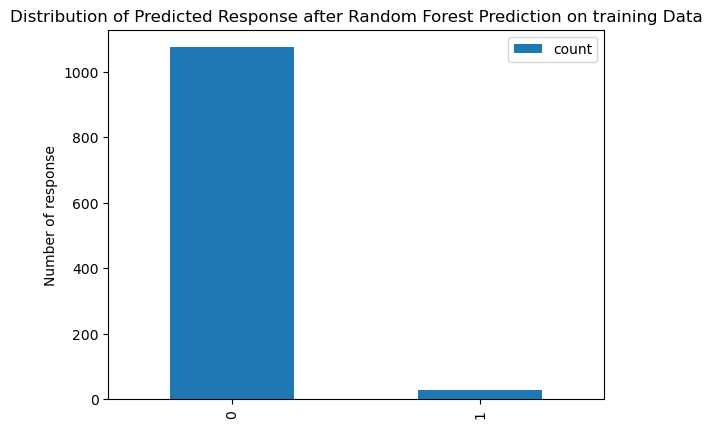

In [389]:
# Using Barplot to show the distribution of predicted responses after Random Forest Prediction
# tally predictions
pd.Series(X_train_pred['Prediction']).value_counts().plot(kind='bar')
plt.title(f'Distribution of Predicted Response after Random Forest Prediction on training Data')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()

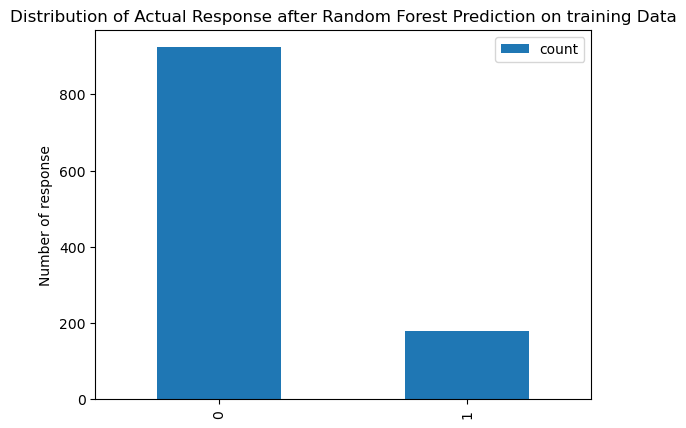

In [390]:
# Using Barplot to show the distribution of predicted responses after Random Forest Prediction
# tally predictions
pd.Series(X_train_pred['Actual']).value_counts().plot(kind='bar')
plt.title(f'Distribution of Actual Response after Random Forest Prediction on training Data')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()

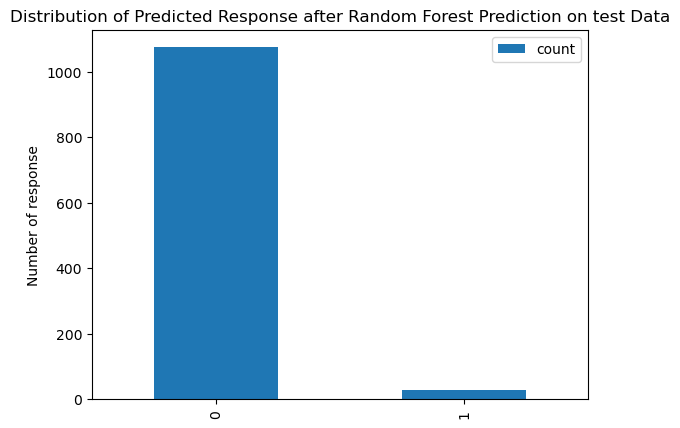

In [391]:
# Using Barplot to show the distribution of actual responses after Random Forest Prediction
# tally predictions
pd.Series(X_test_pred['Prediction']).value_counts().plot(kind='bar')
plt.title(f'Distribution of Predicted Response after Random Forest Prediction on test Data')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()

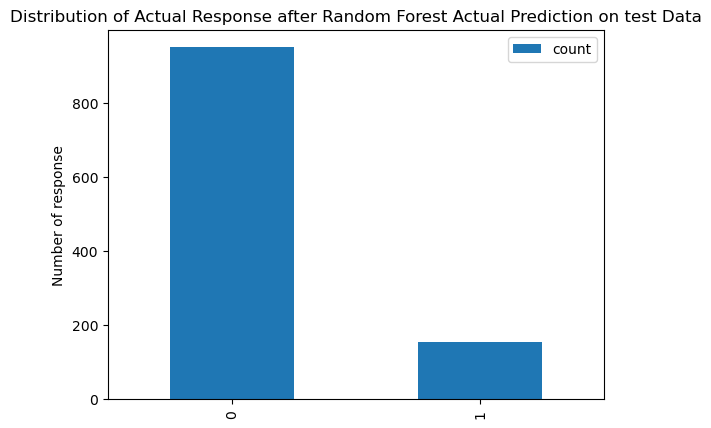

In [392]:
# Using Barplot to show the distribution of actual responses after Random Forest Prediction
# tally predictions
pd.Series(X_test_pred['Actual']).value_counts().plot(kind='bar')
plt.title(f'Distribution of Actual Response after Random Forest Actual Prediction on test Data')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()

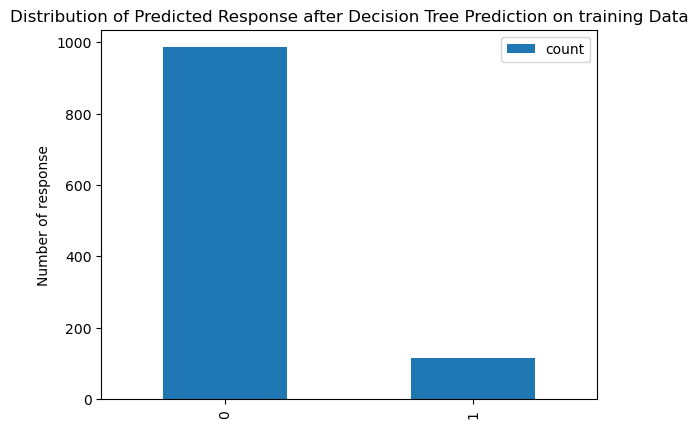

In [393]:
# Using Barplot to show the distribution of predicted responses after Decision Tree Prediction
# tally predictions
pd.Series(X_train_pred_dt['Prediction']).value_counts().plot(kind='bar')
plt.title(f'Distribution of Predicted Response after Decision Tree Prediction on training Data')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()

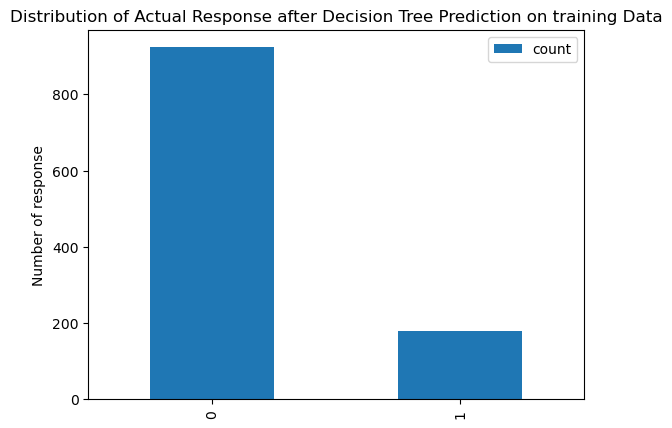

In [394]:
# Using Barplot to show the distribution of predicted responses after Decision Tree Prediction
# tally predictions
pd.Series(X_train_pred_dt['Actual']).value_counts().plot(kind='bar')
plt.title(f'Distribution of Actual Response after Decision Tree Prediction on training Data')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()

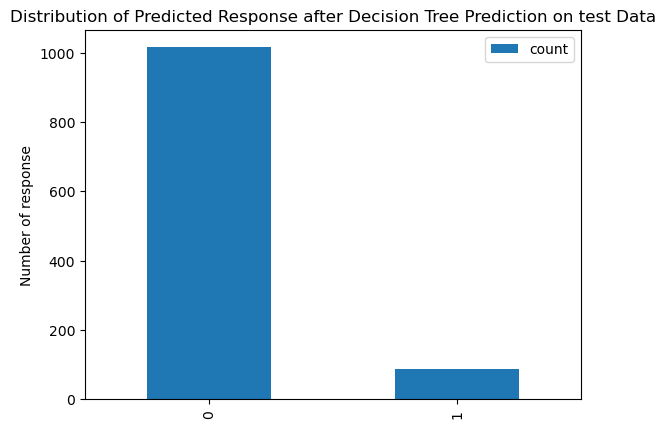

In [395]:
# Using Barplot to show the distribution of actual responses after Decision Tree Prediction
# tally predictions
pd.Series(X_test_pred_dt['Prediction']).value_counts().plot(kind='bar')
plt.title(f'Distribution of Predicted Response after Decision Tree Prediction on test Data')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()

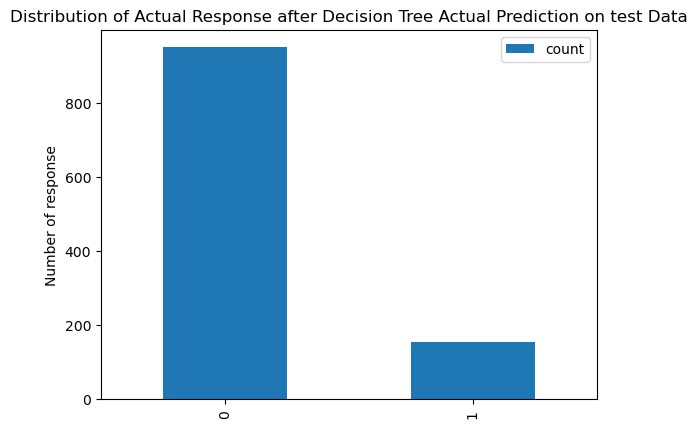

In [396]:
# Using Barplot to show the distribution of actual responses after Decision Tree Prediction
# tally predictions
pd.Series(X_test_pred_dt['Actual']).value_counts().plot(kind='bar')
plt.title(f'Distribution of Actual Response after Decision Tree Actual Prediction on test Data')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()

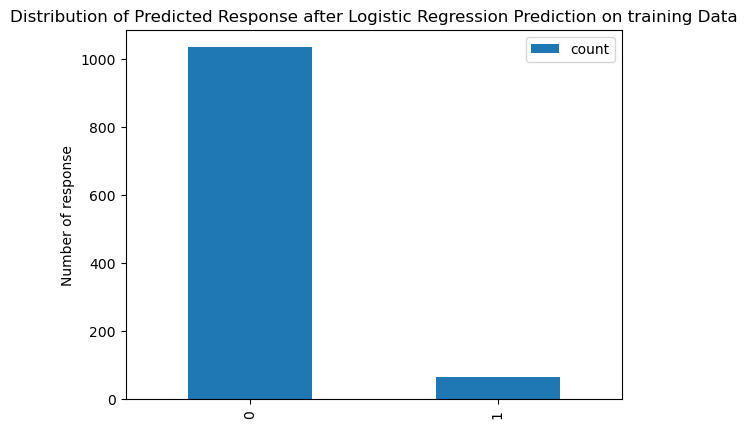

In [397]:
# Using Barplot to show the distribution of predicted responses after Logistic Regression Prediction
# tally predictions
pd.Series(X_train_pred_logr['Prediction']).value_counts().plot(kind='bar')
plt.title(f'Distribution of Predicted Response after Logistic Regression Prediction on training Data')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()

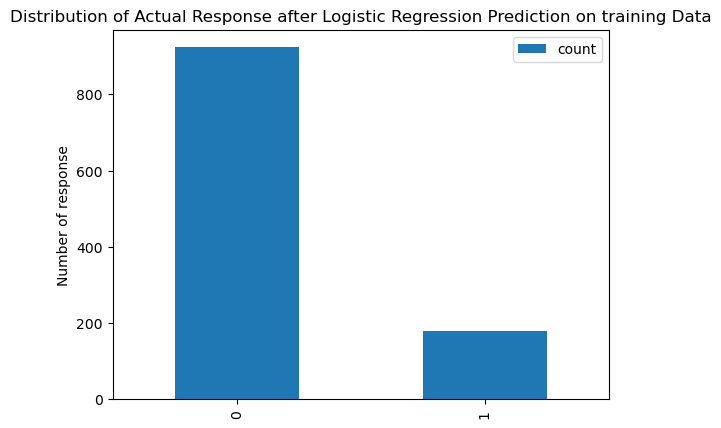

In [398]:
# Using Barplot to show the distribution of predicted responses after Logistic Regression Prediction
# tally predictions
pd.Series(X_train_pred_logr['Actual']).value_counts().plot(kind='bar')
plt.title(f'Distribution of Actual Response after Logistic Regression Prediction on training Data')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()

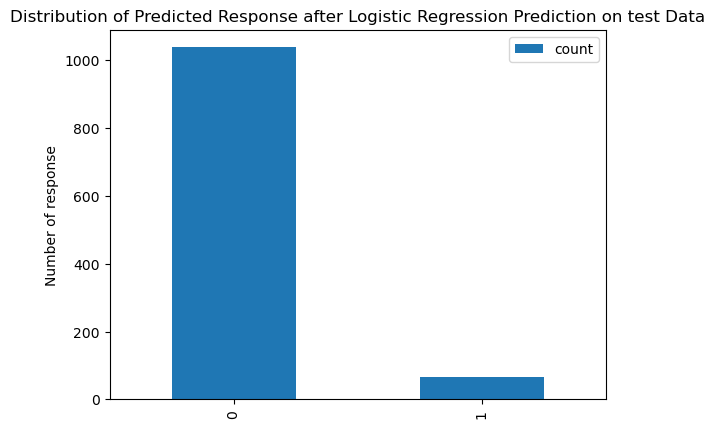

In [399]:
# Using Barplot to show the distribution of predicted responses after Logistic Regression Prediction
# tally predictions
pd.Series(X_test_pred_logr['Prediction']).value_counts().plot(kind='bar')
plt.title(f'Distribution of Predicted Response after Logistic Regression Prediction on test Data')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()

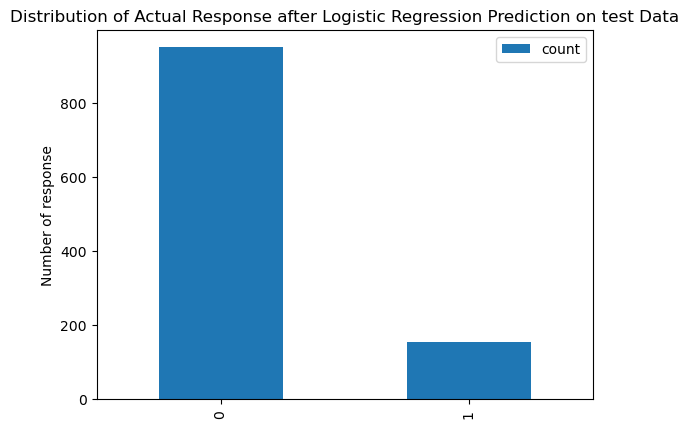

In [400]:
# Using Barplot to show the distribution of predicted responses after Logistic Regression Prediction
# tally predictions
pd.Series(X_test_pred_logr['Actual']).value_counts().plot(kind='bar')
plt.title(f'Distribution of Actual Response after Logistic Regression Prediction on test Data')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()

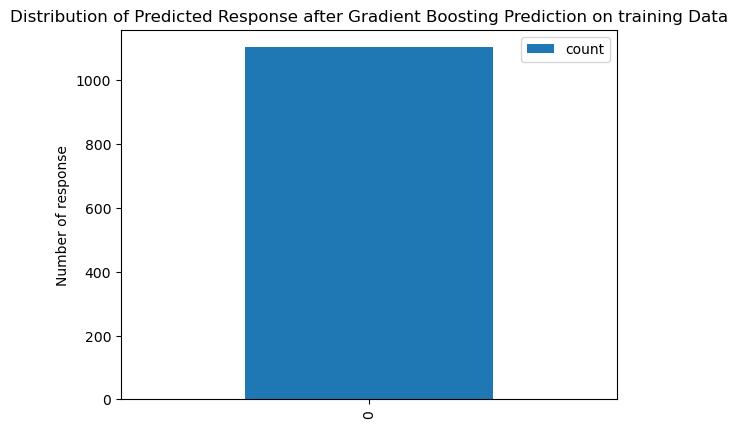

In [401]:
# Using Barplot to show the distribution of predicted responses after Gradient Boosting Prediction
# tally predictions
pd.Series(X_train_pred_gbt['Prediction']).value_counts().plot(kind='bar')
plt.title(f'Distribution of Predicted Response after Gradient Boosting Prediction on training Data')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()

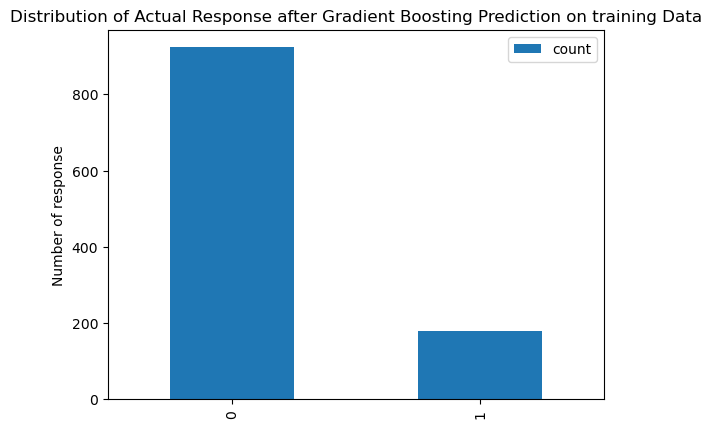

In [402]:
# Using Barplot to show the distribution of predicted responses after Gradient Boosting Prediction
# tally predictions
pd.Series(X_train_pred_gbt['Actual']).value_counts().plot(kind='bar')
plt.title(f'Distribution of Actual Response after Gradient Boosting Prediction on training Data')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()

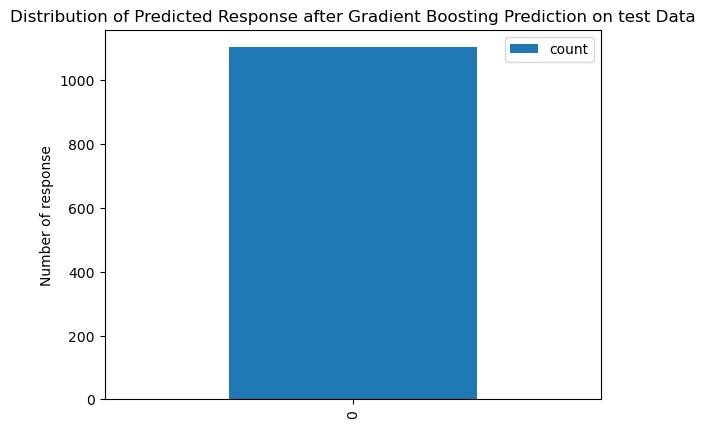

In [403]:
# Using Barplot to show the distribution of predicted responses after Gradient Boosting Prediction
# tally predictions
pd.Series(X_test_pred_gbt['Prediction']).value_counts().plot(kind='bar')
plt.title(f'Distribution of Predicted Response after Gradient Boosting Prediction on test Data')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()

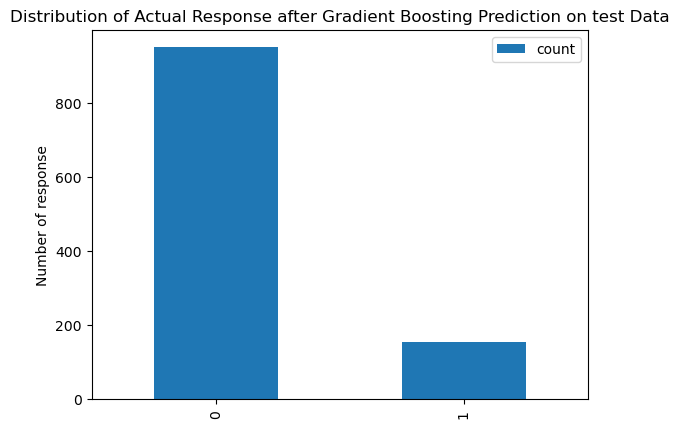

In [404]:
# Using Barplot to show the distribution of predicted responses after Gradient Boosting Prediction
# tally predictions
pd.Series(X_test_pred_gbt['Actual']).value_counts().plot(kind='bar')
plt.title(f'Distribution of Actual Response after Gradient Boosting Prediction on test Data')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()

#### Using Confusion Matrix to Display Response to provide a detailed breakdown of predictions comapred to actual groundtruth labels

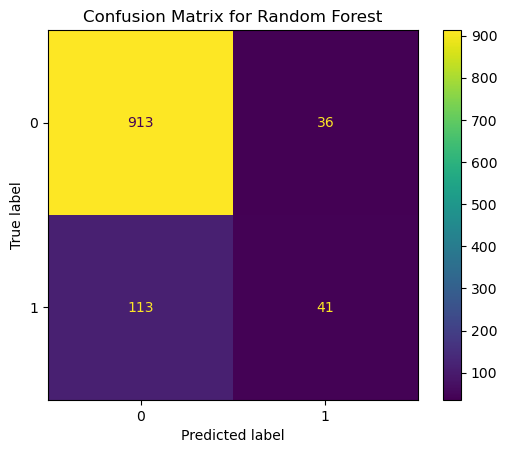

In [405]:
# Confusion Matrix for Random Forest
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
confusion_matrix(y_test, y_pred_rf) 
# True Negative: 917
# False Positive: 32
# False Negative: 101
# True Positive: 53 
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix for Random Forest")

plt.show()


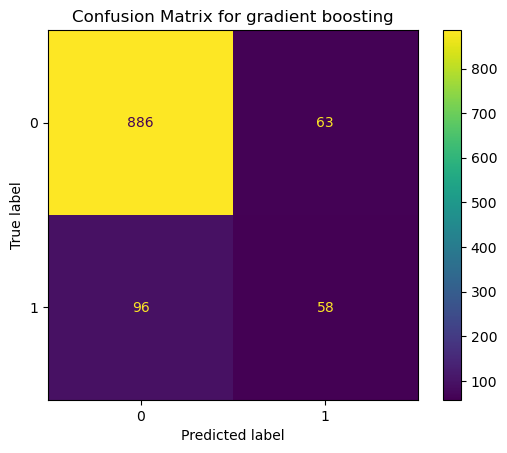

In [406]:
# Confusion Matrix for Gradient Boosted Tree
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred_gbt) 
# True Negative: 903
# False Positive: 46
# False Negative: 90
# True Positive: 64 

cm = confusion_matrix(y_test, y_pred_gbt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix for gradient boosting")
plt.show()

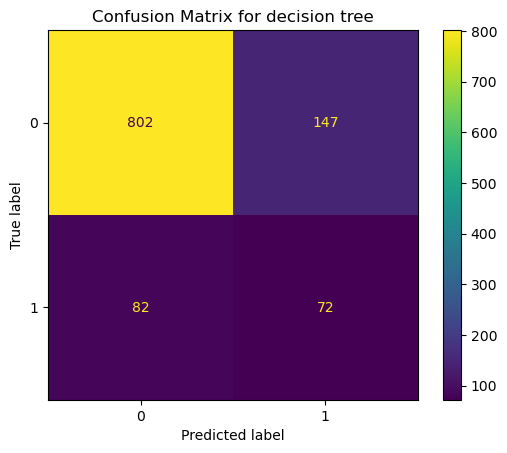

In [407]:
# Confusion Matrix for Decision Tree
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred_dt) 
# True Negative: 822
# False Positive: 127
# False Negative: 90
# True Positive: 64 

cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix for decision tree")
plt.show()

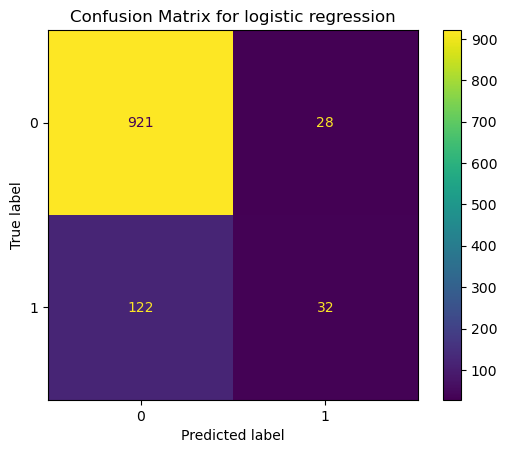

In [408]:
# Confusion Matrix for Logistic Regression
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred_logr) 
# True Negative: 922
# False Positive: 27
# False Negative: 123
# True Positive: 31 
cm = confusion_matrix(y_test, y_pred_logr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix for logistic regression")
plt.show()

##### Recall: Among all the actual positives, how often are predicted right? Important when missing a positive case(false negatives)

##### Low recall: Missed many actual positives

##### precision: Important when false alarms (false postive) are costly

##### High precision: Model is usually right with its prediction
##### Low precision: Model frequently makes false positive predictions


##### F1-score: Harmonic mean of recall and precision("average" but penalizes extreme differences)

##### using these classification metrics to classify imbalance datsets 

In [409]:
# classification_report for Random Forest
from sklearn.metrics import classification_report
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       949
           1       0.53      0.27      0.35       154

    accuracy                           0.86      1103
   macro avg       0.71      0.61      0.64      1103
weighted avg       0.84      0.86      0.85      1103



In [410]:
# classification_report for Decision Tree
from sklearn.metrics import classification_report
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       949
           1       0.33      0.47      0.39       154

    accuracy                           0.79      1103
   macro avg       0.62      0.66      0.63      1103
weighted avg       0.83      0.79      0.81      1103



In [411]:
# classification_report for Logistic Regression
from sklearn.metrics import classification_report
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logr))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       949
           1       0.53      0.21      0.30       154

    accuracy                           0.86      1103
   macro avg       0.71      0.59      0.61      1103
weighted avg       0.83      0.86      0.84      1103



In [412]:
# classification_report for Gradient Boosted Tree
from sklearn.metrics import classification_report
print("Gradient Boosted Tree Classification Report:")
print(classification_report(y_test, y_pred_gbt))

Gradient Boosted Tree Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       949
           1       0.48      0.38      0.42       154

    accuracy                           0.86      1103
   macro avg       0.69      0.66      0.67      1103
weighted avg       0.84      0.86      0.85      1103



In [413]:
from sklearn.metrics import precision_score, recall_score
# Precision and Recall for Random Forest
precision_rf = precision_score(y_test, y_pred_rf,average='binary')
print(f"Random Forest Precision: {precision_rf:.3f}")
recall_rf = recall_score(y_test, y_pred_rf,average='binary')
print(f"Random Forest Recall: {recall_rf:.3f}")

Random Forest Precision: 0.532
Random Forest Recall: 0.266


In [414]:
from sklearn.metrics import precision_score, recall_score
# Precision and Recall for Decision Tree
precision_dt = precision_score(y_test, y_pred_dt,average='binary')
print(f"Decision Tree Precision: {precision_dt:.3f}")
recall_dt = recall_score(y_test, y_pred_dt,average='binary')
print(f"Decision Tree Recall: {recall_dt:.3f}")

Decision Tree Precision: 0.329
Decision Tree Recall: 0.468


In [415]:
from sklearn.metrics import precision_score, recall_score
# Precision and Recall for logistic regression
precision_lr = precision_score(y_test, y_pred_logr,average='binary')
print(f"Logistic Regression Precision: {precision_lr:.3f}")
recall_lr = recall_score(y_test, y_pred_logr,average='binary')
print(f"Logistic Regression Recall: {recall_lr:.3f}")

Logistic Regression Precision: 0.533
Logistic Regression Recall: 0.208


In [416]:
from sklearn.metrics import precision_score, recall_score
# Precision and Recall for gradient boosted tree
precision_gbt = precision_score(y_test, y_pred_gbt,average='binary')
print(f"Gradient Boosted Tree Precision: {precision_gbt:.3f}")
recall_gbt = recall_score(y_test, y_pred_gbt,average='binary')
print(f"Gradient Boosted Tree Recall: {recall_gbt:.3f}")

Gradient Boosted Tree Precision: 0.479
Gradient Boosted Tree Recall: 0.377


In [417]:
from sklearn.metrics import f1_score
# f1 score for gradient boosted tree  
print('f1_score for gradient boosted tree:', f1_score(y_test, y_pred_gbt))
# f1 score for random forest  
print('f1_score for random forest :', f1_score(y_test, y_pred_rf))  

# f1 score for decision tree  
print('f1_score for decision tree:', f1_score(y_test, y_pred_dt))

# f1 score for logistic regression  
print('f1_score for logistic regression:', f1_score(y_test, y_pred_logr))

f1_score for gradient boosted tree: 0.4218181818181818
f1_score for random forest : 0.354978354978355
f1_score for decision tree: 0.38605898123324395
f1_score for logistic regression: 0.29906542056074764


the precision and recall of the models missed actual postives and make false positive predictions and the f1 score showing .

Adjusting decision threshold to increase percision to reduce false positives and recall reduce false negatives

we can improve precision, recall ND F1-Score by using the following below.

In [418]:

# improving precision and recall
# Adjusting the classification threshold by using predict_proba()
y_scores_logr = best_rs_logr.decision_function(X_test) # get probabilities for the positive class
# By default, the classification threshold 
threshold_logr = 0.7
y_pred_adjusted = (y_scores_logr >= threshold_logr).astype(int)

# y_scores_logr_recall = logr.predict_proba(X_test)[:, 1] # get probabilities for the positive class
# By default, the classification threshold 
# recall_threshold = 0.1


# y_recall_adjusted = (y_scores_logr_recall >= recall_threshold).astype(int)
# evaluate adjusted predictions
precision_adjusted_logr = precision_score(y_test, y_pred_adjusted)

print(f"Adjusted Logistic Regression Precision: {precision_adjusted_logr:.3f}")

recall_adjusted = recall_score(y_test, y_pred_adjusted)
print(f"Adjusted Logistic Regression Recall: {recall_adjusted:.3f}")
# logr = (precision_adjusted + recall_adjusted) / 2

# Evaluation and metric using weighted average for adjusted threshold for imabalanced datasets
f1_adjusted_logr = f1_score(y_test, y_pred_adjusted, average='weighted')
print(f"Adjusted Logistic Regression F1 Score: {f1_adjusted_logr:.3f}")

model_artifact_logr = {
    'model': best_rs_logr, # Saving the best fitted model
    'threshold': {
        'value': threshold_logr, # save threshold
        'precision': precision_adjusted_logr, # save precision
        'recall': recall_adjusted, # save recall
        'f1_score': f1_adjusted_logr # f1 score

    },
}
# save model for logistic regression for adjusted threshold
joblib.dump(model_artifact_logr, 'ifood_df_logr_adjusted_threshold_model.joblib')  # Save model


Adjusted Logistic Regression Precision: 0.704
Adjusted Logistic Regression Recall: 0.123
Adjusted Logistic Regression F1 Score: 0.829


['ifood_df_logr_adjusted_threshold_model.joblib']

In [419]:
from sklearn.metrics import precision_recall_curve,recall_score,precision_score
from sklearn.metrics import f1_score,make_scorer

# Improving precision and recall for random forest
# Adjusting the classification threshold by using predict_proba()
threshold_rf = 0.3
y_pred_adjusted_rf = (best_rs_rf.predict_proba(X_test)[:, 1] >= threshold_rf).astype(int)

precision_adjusted_rf = precision_score(y_test, y_pred_adjusted_rf)

# threshold_recall_rf = 0.1
# y_recall_adjusted_rf = (rf.predict_proba(X_test)[:, 1] >= threshold_recall_rf).astype(int)

# threshold_f1_rf = 0.15
# y_f1_adjusted_rf = (rf.predict_proba(X_test)[:, 1] >= threshold_f1_rf).astype(int)

print(f"Adjusted Random Forest Precision: {precision_adjusted_rf:.3f}")

recall_adjusted_rf = recall_score(y_test, y_pred_adjusted_rf)
print(f"Adjusted Random Forest Recall: {recall_adjusted_rf:.3f}")

# Evaluation and metric using weighted average for adjusted threshold for imabalanced datasets
f1_adjusted_rf = f1_score(y_test, y_pred_adjusted_rf, average='weighted')
print(f"Adjusted Random Forest F1 Score: {f1_adjusted_rf:.3f}")

# save model for random forest for adjusted threshold
model_artifact_rf = {
    'model': best_rs_rf,
    'threshold': {
        'precision': precision_adjusted_rf,
        'recall': recall_adjusted_rf,
        'f1_score': f1_adjusted_rf

    },
}

# save model for random forest for adjusted threshold
# joblib.dump(model_artifact_rf, 'ifood_df_rf_adjusted_threshold_model.joblib')  # Save model

Adjusted Random Forest Precision: 0.329
Adjusted Random Forest Recall: 0.325
Adjusted Random Forest F1 Score: 0.813


In [420]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score

# improving precision and recall
# Adjusting the classification threshold by using predict_proba()
y_scores_gbt = best_rs_gbt.predict_proba(X_test)[:, 1]# get probabilities for the positive class
# By default, the classification threshold 
threshold_gbt = 0.36
y_pred_adjusted = (y_scores_gbt >= threshold_gbt).astype(int)

# y_scores_gbt_recall = gbt.predict_proba(X_test)[:, 1] # get probabilities for the positive class
# By default, the classification threshold 
# recall_threshold = 0.1


# y_recall_adjusted = (y_scores_gbt_recall >= recall_threshold).astype(int)
# evaluate adjusted predictions
precision_adjusted = precision_score(y_test, y_pred_adjusted)

print(f"Adjusted Gradient Boosted Tree Precision: {precision_adjusted:.3f}")    
recall_adjusted = recall_score(y_test, y_pred_adjusted)
print(f"Adjusted Gradient Boosted Tree Recall: {recall_adjusted:.3f}")

# Evaluation and metric using weighted average for adjusted threshold for imabalanced datasets
f1_adjusted_gbt = f1_score(y_test, y_pred_adjusted, average='weighted')
print(f"Adjusted Gradient Boosted Tree F1 Score: {f1_adjusted_gbt:.3f}")


model_artifact_gbt = {
    'model': best_rs_gbt,
    'threshold': {
        'precision': precision_adjusted,
        'recall': recall_adjusted,
        'f1_score': f1_adjusted_gbt

    },
}
# save model for gradient boosted tree for adjusted threshold
# joblib.dump(model_artifact_gbt, 'ifood_df_gbt_balanced_adjusted_threshold_model.joblib')  # Save model

Adjusted Gradient Boosted Tree Precision: 0.688
Adjusted Gradient Boosted Tree Recall: 0.071
Adjusted Gradient Boosted Tree F1 Score: 0.816


In [421]:

# improving precision and recall
# Adjusting the classification threshold by using predict_proba()
y_scores_dt = best_rs_dt.predict_proba(X_test)[:, 1]# get probabilities for the positive class
# By default, the classification threshold 
threshol_dt = 0.5
y_pred_adjusted = (y_scores_dt >= threshol_dt).astype(int)

# y_scores_dt_recall = dt.predict_proba(X_test)[:, 1] # get probabilities for the positive class
# By default, the classification threshold 
# recall_threshold = 0.4


# y_recall_adjusted = (y_scores_dt_recall >= recall_threshold).astype(int)
# evaluate adjusted predictions
precision_adjusted = precision_score(y_test, y_pred_adjusted)

print(f"Adjusted Decision Tree Precision: {precision_adjusted:.3f}")    
recall_adjusted = recall_score(y_test, y_pred_adjusted)
print(f"Adjusted Decision Tree Recall: {recall_adjusted:.3f}")
dt_balanced = (precision_adjusted + recall_adjusted) / 2

# Evaluation and metric using weighted average for adjusted threshold for imbalanced datasets
f1_adjusted_dt = f1_score(y_test, y_pred_adjusted, average='weighted')
print(f"Adjusted Decision Tree F1 Score: {f1_adjusted_dt:.3f}")
model_artifact_dt = {
    'model': best_rs_dt,
    'threshold': {
        'precision': precision_adjusted,
        'recall': recall_adjusted,
        'f1_score': f1_adjusted_dt

    },
}
# save model for decision tree for adjusted threshold
# joblib.dump(model_artifact_dt, 'ifood_df_dt_balanced_adjusted_threshold_model.joblib')  # Save model

Adjusted Decision Tree Precision: 0.370
Adjusted Decision Tree Recall: 0.221
Adjusted Decision Tree F1 Score: 0.821


#### Among all the models i would choose Logistic Regression with the highest accuracy f1 score and precision are that mostly right after improvement.

## Iterative model development


### Using feature engineering to solve the curse of dimensionality that space grows exponentiallty with dimensions

In [422]:
## Further feature engineering / feature selection
# Principal Component Analysis
from sklearn.decomposition import PCA
pca = PCA(n_components=5)
pca.fit(X)
            
# explained_var = pca.explained_variance_ratio_

# cumulative_var = np.cumsum(explained_var)
# # tells you each component's contributioon
# print("Variance explained by each component: ",explained_var)
# print("cumulative Variance: ",cumulative_var)

,n_components,5
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [423]:
#one hot encoding categorical columns
X_pca = pca.transform(X)
X_pca 

array([[ 6.56089685e+03,  1.21728399e+03,  1.10584042e+02,
        -2.78423059e+02,  3.46356762e+01],
       [-5.30277277e+03, -6.55655299e+02, -1.49354705e+02,
         2.99831440e+01, -1.93702349e+01],
       [ 1.99881873e+04, -4.21059211e+02,  3.15030758e+01,
         7.26933687e+01, -4.01498274e+01],
       ...,
       [ 5.39300333e+03,  8.73120332e+02, -2.96930306e+02,
         2.71744564e+02, -1.49661445e+01],
       [ 1.76239175e+04, -2.99762617e+02, -1.48693100e+02,
         3.57265819e+01,  1.53710264e+01],
       [ 1.22495645e+03, -6.12704543e+02,  3.56755845e+02,
        -2.83087169e+01, -1.79082861e+01]], shape=(2205, 5))

In [424]:
# create a DataFrame for PCA transformed data to reduce dimensions of dataset to simplify the model
df_pca = pd.DataFrame(data=X_pca, columns=['PC1','PC2','PC3','PC4','PC5'])
print("PCA transformed DataFrame:")
df_pca


PCA transformed DataFrame:


,PC1,PC2,PC3,PC4,PC5
0,6560.896854,1217.283992,110.584042,-278.423059,34.635676
1,-5302.772769,-655.655299,-149.354705,29.983144,-19.370235
2,19988.187299,-421.059211,31.503076,72.693369,-40.149827
3,-24987.795166,54.688661,-234.178054,-10.926902,-7.660704
4,6658.941473,-487.752111,-126.989243,-18.857241,-33.496812
...,...,...,...,...,...
2200,9619.664416,386.599025,1.091293,173.826677,122.619625
2201,12380.104007,-589.854330,-227.319648,236.024195,-30.850655
2202,5393.003329,873.120332,-296.930306,271.744564,-14.966144
2203,17623.917533,-299.762617,-148.693100,35.726582,15.371026


Accuracy score:  0.8658204895738894


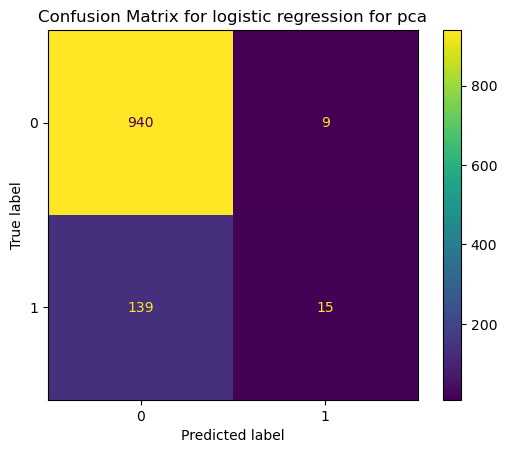

Classification Report: 
               precision    recall  f1-score   support

           0       0.87      0.99      0.93       949
           1       0.62      0.10      0.17       154

    accuracy                           0.87      1103
   macro avg       0.75      0.54      0.55      1103
weighted avg       0.84      0.87      0.82      1103



In [425]:
# Randomized Search CV for feature engineered data
from scipy.stats import randint, uniform
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

## Split data into train set and test set
from sklearn.model_selection import train_test_split
test_size = 0.5
random_state = 20 ## for reproducibility
X_train, X_test, y_train, y_test = train_test_split(df_pca, y, test_size=test_size, random_state=random_state) # Split the data

# use logistic regression as a classifier using train test split

# create LogisticRegression model
pca_logr = LogisticRegression(
    max_iter= 200,
    random_state= 20
)

# fitting the LogisticRegression model
pca_logr.fit(X_train,y_train)

# make predictions
y_pred = pca_logr.predict(X_test)

#Evaluate the model

# Show the accuracy score of pca of logistic regression
print("Accuracy score: ",accuracy_score(y_test,y_pred))
# print("\nConfusion matrix: ",confusion_matrix(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix for logistic regression for pca")
plt.show()

print("Classification Report: \n",classification_report(y_test,y_pred))

#Logisitic Regression was used as a binary classifier.
# The dataset was spilt into training(80%) and testing(20%) sets using a startified train-test split to preserve class distribution
# the model was trained on treaining set and evaluated on unseen test data to measure generalization performance

#### Finding the distribution of Response after Logistic Regression Prediction in pca to see the imbalance.

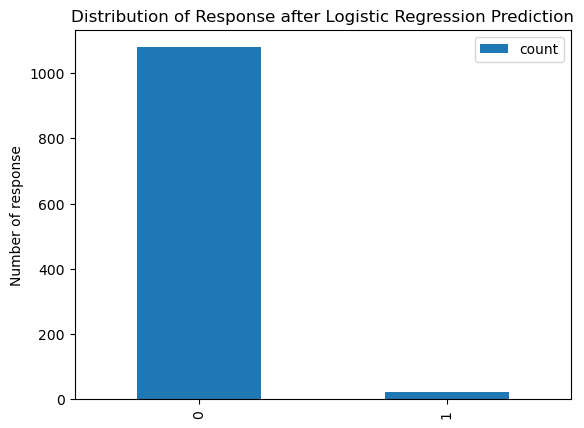

In [426]:
pd.Series(y_pred).value_counts().plot(kind='bar')

plt.title(f'Distribution of Response after Logistic Regression Prediction')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response") 
plt.show()
# Most predicted is 0

In [427]:
# Randomized Search CV
from scipy.stats import randint, uniform

# Randomized Search CV parameters
param_dist_logr_pca = {
    'C': uniform(0.01, 10), #Inverse of regularization strength
    'penalty': ['l2'], #Used to specify the norm used in the penalization
    'solver': ['saga', 'liblinear'], #Algorithm to use in the optimization problem
    'max_iter': randint(100, 500), #Maximum number of iterations taken for the solvers to converge
}

In [428]:
# RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
rs_logr_pca = RandomizedSearchCV(
    estimator = pca_logr, # initialized model
    param_distributions = param_dist_logr_pca,#Search grid (list of parameters)
    cv = 5, # 5 folds for cross validation that divides training set into 5 parts
    scoring = 'f1', # Evaluation used to Evaluate validation set
    n_iter = 10, # number of different combinations to try out
    n_jobs = -1 # Controlling how many CPU cores to use -1: Use all available CPU cores
)
rs_logr_pca.fit(X_train, y_train) # pass training set to model

c:\Users\Yap Kai Feng\anaconda3\envs\mldp\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,estimator,LogisticRegre...ndom_state=20)
,param_distributions,"{'C': <scipy.stats....00276DFD20AE0>, 'max_iter': <scipy.stats....00276E511D940>, 'penalty': ['l2'], 'solver': ['saga', 'liblinear']}"
,n_iter,10
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [429]:
# show best parameters and best estimator for random forest and pca
best_rs_params_pca = rs_logr_pca.best_params_  # TODO: rs_rf.best_params_
best_rs_logr_pca = rs_logr_pca.best_estimator_      # TODO: rs_rf.best_estimator_
print("Best Parameters for PCA: ", best_rs_params_pca)
print("Best Estimator for PCA: ", best_rs_logr_pca)

Best Parameters for PCA:  {'C': np.float64(7.240017703076234), 'max_iter': 433, 'penalty': 'l2', 'solver': 'saga'}
Best Estimator for PCA:  LogisticRegression(C=np.float64(7.240017703076234), max_iter=433,
                   random_state=20, solver='saga')


#### using hyperparameter tuning for RandomizedSearchCV on PCA to decide on best parameters and estimators.

In [430]:
#predict on training set for logistic regression
y_train_pred_logr_pca = best_rs_logr_pca.predict(X_train)  # TODO: model.predict(...)

# make a copy of X_train to store predictions
X_train_pred_logr_pca = X_train.copy()
X_train_pred_logr_pca['Prediction'] = y_train_pred_logr_pca  # TODO: assign y_train_pred_logr to new column 'Prediction'
X_train_pred_logr_pca
X_train_pred_logr_pca['Actual'] = y_train  # TODO: assign y_train to new column 'Actual'
X_train_pred_logr_pca

,PC1,PC2,PC3,PC4,PC5,Prediction,Actual
232,28552.690579,714.183184,-1.265365,370.023326,17.664973,1,1
665,14174.945440,307.537695,-213.675747,-68.910842,58.669005,1,0
259,-22320.531828,-48.460991,-272.814435,4.136445,-9.862226,0,0
1844,-24992.494681,32.203471,-248.570605,1.264713,-1.228407,0,0
744,23488.929954,-914.926617,-187.578727,-90.507085,178.587942,0,0
...,...,...,...,...,...,...,...
552,-13442.189666,-317.725853,256.549040,-26.580254,-34.997331,0,0
1607,1208.879623,-718.498771,-149.675039,82.031157,-31.264389,0,0
1814,-19318.522273,78.699475,130.472489,-35.285486,-16.088895,0,0
1428,-11337.327140,-372.568975,-32.250929,10.514624,-21.282596,0,0


In [431]:
#predict on test set for logistic regression
y_test_pred_logr_pca = best_rs_logr_pca.predict(X_test)  # TODO: model.predict(...)
# make a copy of X_test to store predictions
X_test_pred_logr_pca = X_test.copy()
X_test_pred_logr_pca['Prediction'] = y_test_pred_logr_pca  # TODO: assign y_test_pred_logr to new column 'Prediction'
X_test_pred_logr_pca
X_test_pred_logr_pca['Actual'] = y_test  # TODO: assign y_test to new column 'Actual'
X_test_pred_logr_pca

,PC1,PC2,PC3,PC4,PC5,Prediction,Actual
809,-35100.120210,358.309229,-299.454961,-10.111358,-5.342947,0,0
1766,30519.307862,35.975023,-26.016056,52.787665,46.862812,1,0
2043,20236.440346,-590.070463,-94.551084,-122.188716,-68.559305,0,0
1579,-24518.464613,24.686450,-249.259393,-3.835217,-5.851562,0,0
937,2078.044641,12.017637,319.594215,-123.814238,47.535716,1,0
...,...,...,...,...,...,...,...
1973,15857.687984,-1051.934919,-21.195571,1.214029,13.243583,0,0
1888,680.396960,737.710770,116.348041,426.569251,115.114697,1,0
978,1237.577066,390.316046,-101.177696,-108.101727,25.156983,1,0
798,14064.323542,-222.892313,-192.564657,328.680932,13.345688,0,0


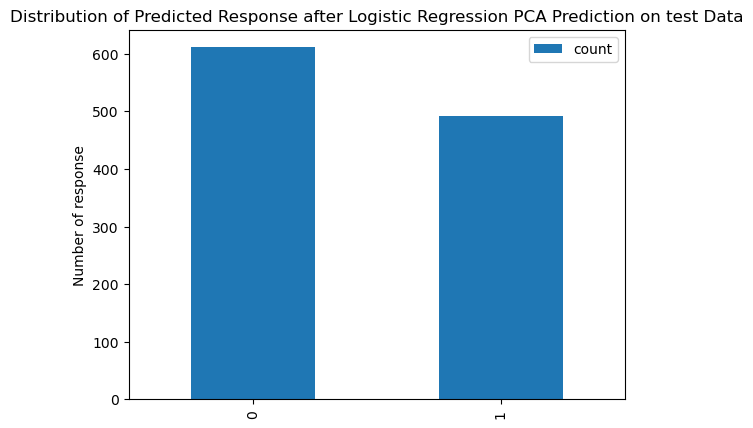

In [432]:
# Using Barplot to show the distribution of predicted responses after Logistic Regression Prediction
# tally predictions
pd.Series(X_test_pred_logr_pca['Prediction']).value_counts().plot(kind='bar')
plt.title(f'Distribution of Predicted Response after Logistic Regression PCA Prediction on test Data')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()

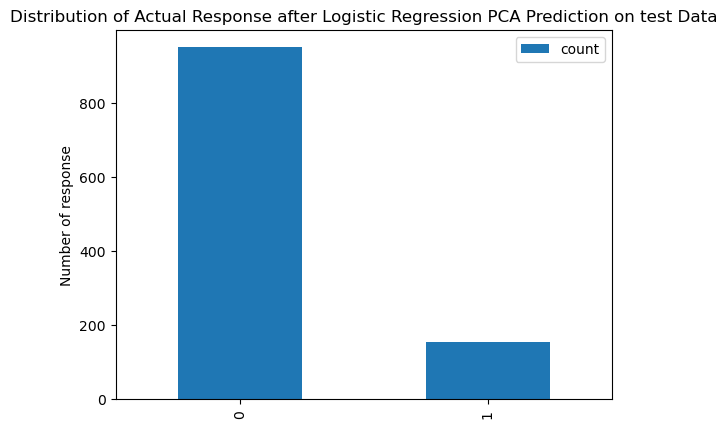

In [433]:
# Using Barplot to show the distribution of predicted responses after Logistic Regression Prediction
# tally predictions
pd.Series(X_test_pred_logr_pca['Actual']).value_counts().plot(kind='bar')
plt.title(f'Distribution of Actual Response after Logistic Regression PCA Prediction on test Data')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()
# shows that imbalanced data in actual response on test data

shows that imbalanced data in actual response on test data

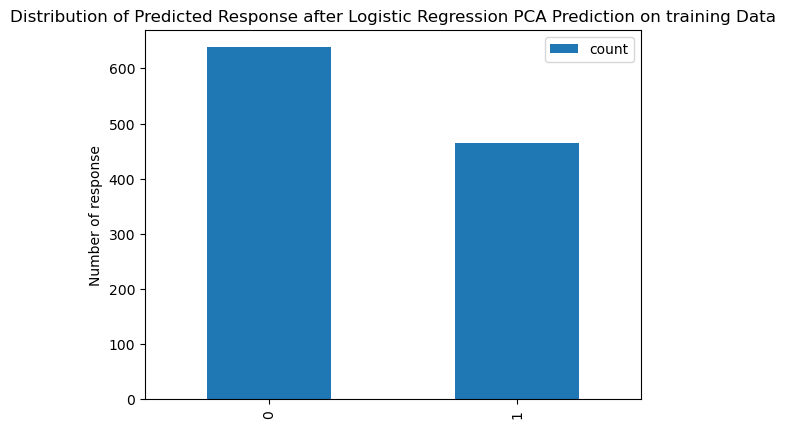

In [434]:
# Using Barplot to show the distribution of predicted responses after Decision Tree Prediction
# tally predictions
pd.Series(X_train_pred_logr_pca['Prediction']).value_counts().plot(kind='bar')
plt.title(f'Distribution of Predicted Response after Logistic Regression PCA Prediction on training Data')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()

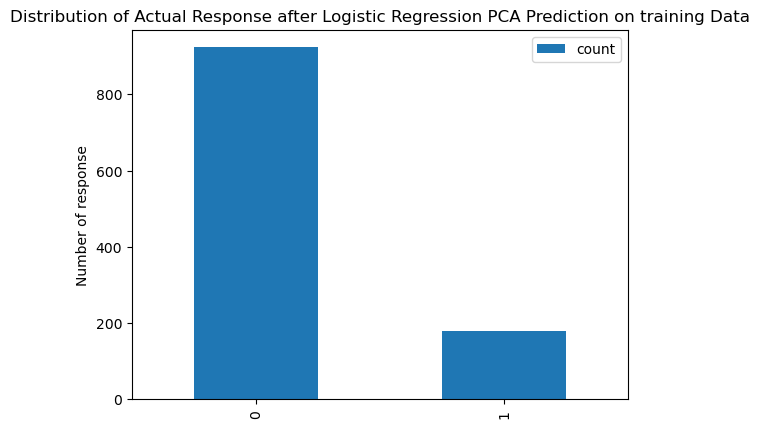

In [435]:
# Using Barplot to show the distribution of predicted responses after Decision Tree Prediction
# tally predictions
pd.Series(X_train_pred_logr_pca['Actual']).value_counts().plot(kind='bar')
plt.title(f'Distribution of Actual Response after Logistic Regression PCA Prediction on training Data')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response")
plt.show()

In [436]:
from sklearn.metrics import precision_score, recall_score,f1_score
# Precision and Recall for logistic regression
precision_lr = precision_score(y_test, y_pred,average='binary')
print(f"Logistic Regression Precision PCA: {precision_lr:.3f}")
recall_lr = recall_score(y_test, y_pred,average='binary')
print(f"Logistic Regression Recall PCA: {recall_lr:.3f}")
# f1 score for logistic regression  
print('f1_score for logistic regression PCA:', f1_score(y_test, y_pred))

Logistic Regression Precision PCA: 0.625
Logistic Regression Recall PCA: 0.097
f1_score for logistic regression PCA: 0.16853932584269662


After PCA, F1 score did not improve.

In [437]:

# improving precision and recall
# Adjusting the classification threshold by using predict_proba()
y_scores_logr = best_rs_logr_pca.decision_function(X_test) # get probabilities for the positive class
# By default, the classification threshold 
threshold_logr = 0.9
y_pred_adjusted = (y_scores_logr >= threshold_logr).astype(int)

# y_scores_logr_recall = logr.predict_proba(X_test)[:, 1] # get probabilities for the positive class
# By default, the classification threshold 
# recall_threshold = 0.1


# y_recall_adjusted = (y_scores_logr_recall >= recall_threshold).astype(int)
# evaluate adjusted predictions
precision_adjusted_logr = precision_score(y_test, y_pred_adjusted)

print(f"Adjusted Logistic Regression PCA Precision: {precision_adjusted_logr:.3f}")

recall_adjusted = recall_score(y_test, y_pred_adjusted)
print(f"Adjusted Logistic Regression PCA Recall: {recall_adjusted:.3f}")
# logr = (precision_adjusted + recall_adjusted) / 2

# Evaluation and metric using weighted average for adjusted threshold for imabalanced datasets
f1_adjusted_logr = f1_score(y_test, y_pred_adjusted, average='weighted')
print(f"Adjusted Logistic Regression PCA F1 Score: {f1_adjusted_logr:.3f}")

model_artifact_logr = {
    'model': logr,
    'threshold': {
        'precision': precision_adjusted_logr,
        'recall': recall_adjusted,
        'f1_score': f1_adjusted_logr

    },
}
# save model for logistic regression for adjusted threshold
# joblib.dump(model_artifact_logr, 'ifood_df_logr_pca_adjusted_threshold_model.joblib')  # Save model


Adjusted Logistic Regression PCA Precision: 0.434
Adjusted Logistic Regression PCA Recall: 0.214
Adjusted Logistic Regression PCA F1 Score: 0.829


#### Logistic Regression:
#### Adjusted Logistic Regression Precision: 0.618
#### Adjusted Logistic Regression Recall: 0.136
#### Adjusted Logistic Regression F1 Score: 0.829
#### This shows that PCA precision did not improve comparing to previous Logistic Regression 

In [438]:
# Clustering using KMeans
# Using Clustering for feature engineering to add cluster labels as new features
# using enriched dataset (original dataset + cluster labels) in supervised learning for classification
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X)

# Get cluster labels for each data point
cluster_labels = kmeans.labels_


c:\Users\Yap Kai Feng\anaconda3\envs\mldp\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


c:\Users\Yap Kai Feng\anaconda3\envs\mldp\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\Yap Kai Feng\anaconda3\envs\mldp\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\Yap Kai Feng\anaconda3\envs\mldp\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\Yap Kai Feng\anaconda3\envs\mldp\Lib\site-packages\sklearn\cluster\_kmeans.p

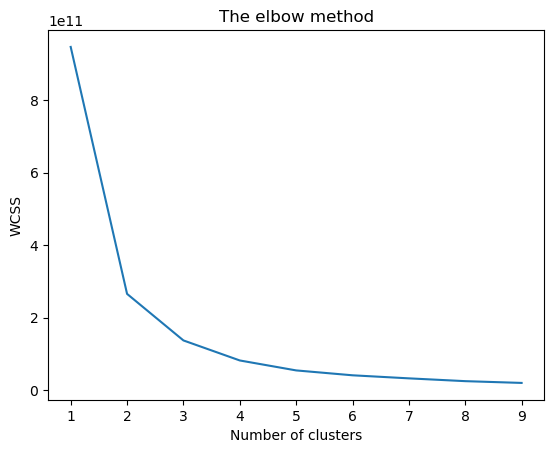

In [439]:
## Elbow method to find optimal number of clusters
WCSS = []
 
for clusters in range(1,10):
    kmeans = KMeans(n_clusters=clusters)
    kmeans.fit(X)
    WCSS.append(kmeans.inertia_)
 
plt.plot(range(1,10), WCSS)
plt.title('The elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()
#choose 3 clusters based on elbow method
#WCSS decreases significantly up to 3 clusters, after which the decrease becomes more gradual

In [440]:
# add cluster lavels as a new feature
X_enriched = X.copy()
X_enriched['cluster_label'] = cluster_labels

Accuracy score:  0.8549410698096102


c:\Users\Yap Kai Feng\anaconda3\envs\mldp\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


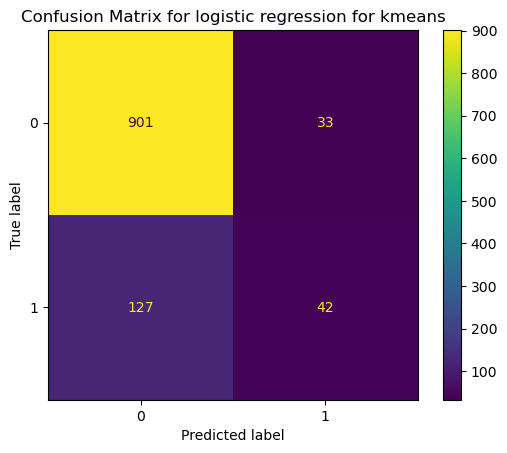

Classification Report: 
               precision    recall  f1-score   support

           0       0.88      0.96      0.92       934
           1       0.56      0.25      0.34       169

    accuracy                           0.85      1103
   macro avg       0.72      0.61      0.63      1103
weighted avg       0.83      0.85      0.83      1103



In [441]:
# Randomized Search CV for feature engineered data
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV


## Split data into train set and test set
from sklearn.model_selection import train_test_split
test_size = 0.5
random_state = 10 ## for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X_enriched, y, test_size=test_size, random_state=random_state) # Split the data

# use logistic regression as a classifier using train test split

# create LogisticRegression model
kmeans_logr = LogisticRegression(
    max_iter= 1000, # 1000 interations
    random_state= 10
)

# fitting the LogisticRegression model
kmeans_logr.fit(X_train,y_train)

# make predictions
y_pred_kmeans = kmeans_logr.predict(X_test)

#Evaluate the model

# Show the accuracy score of pca of logistic regression
print("Accuracy score: ",accuracy_score(y_test,y_pred_kmeans))
# print("\nConfusion matrix: ",confusion_matrix(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred_kmeans)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix for logistic regression for kmeans")
plt.show()

print("Classification Report: \n",classification_report(y_test,y_pred_kmeans))

#Logisitic Regression was used as a binary classifier.
# The dataset was spilt into training(80%) and testing(20%) sets using a startified train-test split to preserve class distribution
# the model was trained on treaining set and evaluated on unseen test data to measure generalization performance

there are no reponses that voted 1 in kmeans

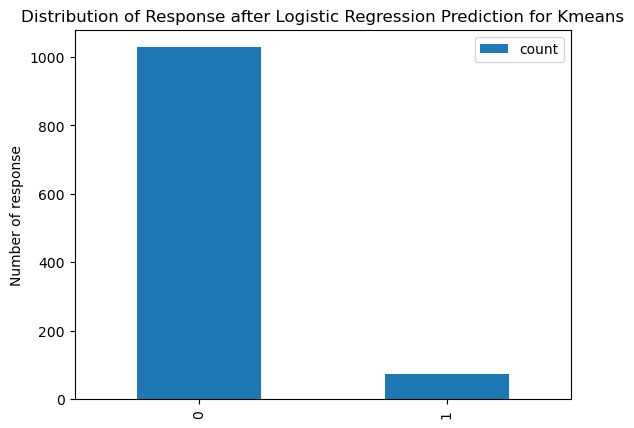

In [442]:
pd.Series(y_pred_kmeans).value_counts().plot(kind='bar')

plt.title(f'Distribution of Response after Logistic Regression Prediction for Kmeans')
plt.legend()
plt.xlabel("")
plt.ylabel("Number of response") 
plt.show()

Imbalanced distribution

In [443]:
# Randomized Search CV
from scipy.stats import randint, uniform

# Randomized Search CV parameters
param_dist_logr_kmeans = {
    'C': uniform(0.01, 10), #Inverse of regularization strength
    'penalty': ['l2'], #Used to specify the norm used in the penalization
    'solver': ['saga', 'liblinear'], #Algorithm to use in the optimization problem
    'max_iter': randint(100, 500), #Maximum number of iterations taken for the solvers to converge
}

In [444]:
# RandomizedSearchCV for KMeans transformed data
from sklearn.model_selection import RandomizedSearchCV
rs_kmeans = RandomizedSearchCV(
    estimator = kmeans_logr, # initialized model
    param_distributions = param_dist_logr_kmeans,#Search grid (list of parameters)
    cv = 5, # 5 folds for cross validation that divides training set into 5 parts
    scoring = 'f1', # Evaluation used to Evaluate validation set
    n_iter = 10, # number of different combinations to try out
    n_jobs = -1 # Controlling how many CPU cores to use -1: Use all available CPU cores
)
rs_kmeans.fit(X_train, y_train) # pass training set to model


,estimator,LogisticRegre...ndom_state=10)
,param_distributions,"{'C': <scipy.stats....00276E1133F50>, 'max_iter': <scipy.stats....00276E54C7310>, 'penalty': ['l2'], 'solver': ['saga', 'liblinear']}"
,n_iter,10
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [445]:
# show best parameters and best estimator for random forest and kmeans clustering
best_rs_params = rs_kmeans.best_params_  # TODO: rs_rf.best_params_
best_rs_kmeans = rs_kmeans.best_estimator_      # TODO: rs_rf.best_estimator_
print("Best Parameters for KMeans: ", best_rs_params)
print("Best Estimator for KMeans: ", best_rs_kmeans)

Best Parameters for KMeans:  {'C': np.float64(6.464497595571182), 'max_iter': 128, 'penalty': 'l2', 'solver': 'liblinear'}
Best Estimator for KMeans:  LogisticRegression(C=np.float64(6.464497595571182), max_iter=128,
                   random_state=10, solver='liblinear')


#### using hyperparameter tuning for RandomizedSearchCV on KMeans Clustering to decide on best parameters and estimators.

In [446]:
#predict on test set for logistic regression
y_test_pred_logr_kmeans = best_rs_kmeans.predict(X_test)  # TODO: model.predict(...)
# make a copy of X_test to store predictions
X_test_pred_logr_kmeans = X_test.copy()
X_test_pred_logr_kmeans['Prediction'] = y_test_pred_logr_pca  # TODO: assign y_test_pred_logr to new column 'Prediction'
X_test_pred_logr_kmeans
X_test_pred_logr_kmeans['Actual'] = y_test  # TODO: assign y_test to new column 'Actual'
X_test_pred_logr_kmeans

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,education_2n_Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,cluster_label,Prediction,Actual
1418,78427,0,0,36,972,19,556,120,26,126,...,0,0,0,1,0,1792,1654,1,0,1
980,78028,0,1,38,158,19,288,25,0,38,...,0,0,0,0,1,490,452,1,1,1
1911,54356,0,1,62,710,15,30,20,0,0,...,0,0,0,0,1,775,775,0,0,1
1534,70179,0,1,10,532,79,168,69,44,126,...,0,0,0,0,1,901,768,1,0,0
955,83715,0,0,2,318,8,407,120,35,8,...,0,0,1,0,0,918,910,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1585,68655,0,0,95,456,19,556,75,83,38,...,0,0,1,0,0,1500,1462,1,0,0
1873,59292,0,1,71,378,14,68,19,14,14,...,0,0,0,0,1,493,479,0,1,0
1770,62535,0,1,13,163,48,90,0,45,52,...,0,0,1,0,0,346,294,0,1,0
1435,64866,0,1,9,508,5,21,7,5,10,...,0,0,0,1,0,546,536,1,0,0


In [447]:
from sklearn.metrics import precision_score, recall_score,f1_score
# Precision and Recall for logistic regression
precision_lr = precision_score(y_test, y_pred_kmeans,average='binary')
print(f"Logistic Regression Kmeans Precision: {precision_lr:.3f}")
recall_lr = recall_score(y_test, y_pred_kmeans,average='binary')
print(f"Logistic Regression Kmeans Recall: {recall_lr:.3f}")
# f1 score for logistic regression  
print('f1_score for kmeans:', f1_score(y_test, y_pred_kmeans))

Logistic Regression Kmeans Precision: 0.560
Logistic Regression Kmeans Recall: 0.249
f1_score for kmeans: 0.3442622950819672


In [448]:

# improving precision and recall
# Adjusting the classification threshold by using predict_proba()
y_scores_kmeans = best_rs_kmeans.decision_function(X_test) # get probabilities for the positive class
# By default, the classification threshold 
threshold_logr = 0.6
y_pred_adjusted = (y_scores_kmeans >= threshold_logr).astype(int)

# y_scores_logr_recall = logr.predict_proba(X_test)[:, 1] # get probabilities for the positive class
# By default, the classification threshold 
# recall_threshold = 0.1


# y_recall_adjusted = (y_scores_logr_recall >= recall_threshold).astype(int)
# evaluate adjusted predictions
precision_adjusted_kmeans = precision_score(y_test, y_pred_adjusted)

print(f"Adjusted Logistic Regression Kmeans Precision: {precision_adjusted_kmeans:.3f}")

recall_adjusted_kmeans = recall_score(y_test, y_pred_adjusted)
print(f"Adjusted Logistic Regression Kmeans Recall: {recall_adjusted_kmeans:.3f}")
# logr = (precision_adjusted + recall_adjusted) / 2

# Evaluation and metric using weighted average for adjusted threshold for imabalanced datasets
f1_adjusted_kmeans = f1_score(y_test, y_pred_adjusted, average='weighted')
print(f"Adjusted Logistic Regression Kmeans F1 Score: {f1_adjusted_kmeans:.3f}")

model_artifact_logr = {
    'model': logr,
    'threshold': {
        'precision': precision_adjusted_kmeans,
        'recall': recall_adjusted_kmeans,
        'f1_score': f1_adjusted_kmeans

    },
}
# save model for logistic regression for adjusted threshold
# joblib.dump(model_artifact_logr, 'ifood_df_logr_pca_adjusted_threshold_model.joblib')  # Save model


Adjusted Logistic Regression Kmeans Precision: 0.614
Adjusted Logistic Regression Kmeans Recall: 0.160
Adjusted Logistic Regression Kmeans F1 Score: 0.818


#### Logistic Regression:
#### Adjusted Logistic Regression Precision: 0.750
#### Adjusted Logistic Regression Recall: 0.156
#### Adjusted Logistic Regression F1 Score: 0.838

#### PCA:
#### Adjusted Logistic Regression PCA Precision: 0.427
#### Adjusted Logistic Regression PCA Recall: 0.208
#### Adjusted Logistic Regression PCA F1 Score: 0.828

#### Kmeans
#### Adjusted Logistic Regression Kmeans Precision: 0.656
#### Adjusted Logistic Regression Kmeans Recall: 0.124
#### Adjusted Logistic Regression Kmeans F1 Score: 0.812

#### Altough kmeans precision and recall improved, but it did not help to improve the f1 score or recall compared to original Logistic Regression model